# Tier 1 — Sparse Retrieval: Full Analysis

**Benchmark:** BSARD official test split — 222 questions  
**Experiments:** 12 sparse retrieval systems (BM25, TF-IDF, FTS5)  
**Results directory:** `output/results/sparse_retrieval/`

Sections: 0. Setup | 1. Replication check | 2. Recall@k curves | 3. Normalization ablation | 4. Field weighting | 5. BM25 variants | 6. Hyperparameter tuning | 7. TF-IDF vs BM25 | 8. Latency (Tier 0) | 9. Stratified analysis | 10. Significance testing | 11. Tier 3 config selection | 12. Subset metrics | 13. Tier 3 autonomous evaluation | 14. Supervised vs autonomous correlation | 15. Per-component deep dive | 16. UMBRELA bridge | 17. Complete results table

## 0. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

RESULTS_DIR      = Path("../../output/results/sparse_retrieval")
PAPER_BM25_R100  = 0.5133
PAPER_TFIDF_R100 = 0.4013
PAPER_BM25_MRR   = 0.2459
PAPER_TFIDF_MRR  = 0.1298

raw = {}
for f in sorted(RESULTS_DIR.glob("*_test.json")):
    d = json.loads(f.read_text(encoding="utf-8"))
    key = d["experiment_id"].replace("_test", "")
    raw[key] = d

print(f"Loaded {len(raw)} experiments:")
for k in raw:
    print(f"  {k}")


Loaded 12 experiments:
  bm25_anchor
  bm25_l_lemmatize
  bm25_lemmatize_concat_2x
  bm25_lemmatize_text_only
  bm25_none_concat_2x
  bm25_plus_lemmatize
  bm25_stem_text_only
  bm25_tuned_k11.5_b0.25
  fts5_default
  tfidf_lemmatize_concat_2x
  tfidf_lemmatize_text_only
  tfidf_none_text_only


In [2]:
rows = []
for exp, d in raw.items():
    m, ld, sig, hp, pp = (d["metrics"], d["latency_distribution"],
                          d["significance_vs_anchor"], d["hyperparameters"], d["preprocessing"])
    rows.append({
        "experiment": exp, "method": d["model_or_method"],
        "norm": pp["normalization"], "fw": pp["field_weighting"],
        "variant": hp.get("variant", "-"),
        "R@1": m.get("Recall@1", 0), "R@5": m.get("Recall@5", 0),
        "R@10": m.get("Recall@10", 0), "R@20": m.get("Recall@20", 0),
        "R@50": m.get("Recall@50", 0), "R@100": m.get("Recall@100", 0),
        "R@200": m.get("Recall@200", 0),
        "MRR@100": m.get("MRR@100", 0), "MAP@100": m.get("MAP@100", 0),
        "NDCG@10": m.get("NDCG@10", 0), "NDCG@100": m.get("NDCG@100", 0),
        "P@10": m.get("Precision@10", 0), "F1@10": m.get("F1@10", 0),
        "HR@10": m.get("HitRate@10", 0),
        "lat_mean": ld["mean"], "lat_std": ld["std"],
        "lat_p50": ld["p50"], "lat_p90": ld["p90"], "lat_p99": ld["p99"],
        "idx_build_s": ld["index_build_s"],
        "p_val": sig.get("p_value_recall10"), "sig": sig.get("significant"),
    })

df = pd.DataFrame(rows).sort_values("R@100", ascending=False).reset_index(drop=True)
display_cols = ["experiment", "R@10", "R@100", "MRR@100", "NDCG@10", "MAP@100", "lat_mean", "p_val", "sig"]
df[display_cols].style \
    .format({c: "{:.4f}" for c in ["R@10", "R@100", "MRR@100", "NDCG@10", "MAP@100"]}) \
    .format({"lat_mean": "{:.1f}", "p_val": lambda x: f"{x:.3f}" if x is not None else "—"}) \
    .background_gradient(subset=["R@100"], cmap="YlGn") \
    .background_gradient(subset=["R@10"],  cmap="Blues") \
    .set_caption("All 12 experiments — sorted by R@100 (primary metric)")


,experiment,R@10,R@100,MRR@100,NDCG@10,MAP@100,lat_mean,p_val,sig
0,bm25_lemmatize_concat_2x,0.257232,0.531194,0.251976,0.210243,0.167770,69.7,0.600,False
1,bm25_tuned_k11.5_b0.25,0.265090,0.520983,0.262759,0.222094,0.181904,76.1,0.374,False
2,tfidf_lemmatize_concat_2x,0.200334,0.515186,0.199529,0.153009,0.112228,39.9,0.037,True
3,bm25_lemmatize_text_only,0.238110,0.512094,0.251954,0.202910,0.162135,66.0,0.620,False
4,bm25_plus_lemmatize,0.246103,0.508793,0.255179,0.206791,0.164331,86.5,0.938,False
5,bm25_none_concat_2x,0.256711,0.500885,0.245429,0.202617,0.161541,140.6,0.056,False
6,bm25_stem_text_only,0.263695,0.490538,0.249534,0.210265,0.163111,66.5,0.422,False
7,bm25_anchor,0.247617,0.482054,0.246324,0.201097,0.161643,136.1,nan,None
8,tfidf_lemmatize_text_only,0.173034,0.479256,0.164625,0.127628,0.086958,39.2,0.001,True
9,fts5_default,0.236517,0.469729,0.236728,0.190300,0.150513,58.1,0.549,False


## A0. Full Results by Metric Family — All Methods × All k Values

One table per metric family across **k ∈ {1, 5, 10, 20, 50, 100, 200, 500}** for all 12 experiments on the BSARD test split (n=222), sorted by the @100 column.

**Paper reference rows** (Masson & Joty 2022, 40k-article corpus) are appended in italic where values are available (Recall@100 and MRR@100 only).

Bold = best value per column among our experiments; italic rows = paper reference (not ranked).

In [3]:
SHORT_NAMES = {
    "bm25_anchor":              "BM25 Okapi | none | text_only (anchor)",
    "bm25_lemmatize_text_only": "BM25 Okapi | lemmatize | text_only",
    "bm25_stem_text_only":      "BM25 Okapi | stem | text_only",
    "bm25_none_concat_2x":      "BM25 Okapi | none | concat_2x",
    "bm25_lemmatize_concat_2x": "BM25 Okapi | lemmatize | concat_2x",
    "bm25_tuned_k11.5_b0.25":   "BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25",
    "bm25_plus_lemmatize":      "BM25+ | lemmatize | text_only",
    "bm25_l_lemmatize":         "BM25L | lemmatize | text_only",
    "fts5_default":             "FTS5 | none | text_only",
    "tfidf_none_text_only":     "TF-IDF | none | text_only",
    "tfidf_lemmatize_text_only":"TF-IDF | lemmatize | text_only",
    "tfidf_lemmatize_concat_2x":"TF-IDF | lemmatize | concat_2x",
}

K_VALS = [1, 5, 10, 20, 50, 100, 200, 500]

# Paper reference values (40k corpus, Masson & Joty 2022 Table 2)
PAPER_REFS = {
    "Recall":    {"BM25 Okapi (paper, 40k)": {100: 0.5133}, "TF-IDF (paper, 40k)": {100: 0.4013}},
    "MRR":       {"BM25 Okapi (paper, 40k)": {100: 0.2459}, "TF-IDF (paper, 40k)": {100: 0.1298}},
}

METRIC_FAMILIES = [
    ("Recall",    "Recall@{}",    "R@{}"),
    ("MRR",       "MRR@{}",       "MRR@{}"),
    ("NDCG",      "NDCG@{}",      "NDCG@{}"),
    ("MAP",       "MAP@{}",       "MAP@{}"),
    ("Precision", "Precision@{}", "P@{}"),
    ("HitRate",   "HitRate@{}",   "HR@{}"),
    ("F1",        "F1@{}",        "F1@{}"),
]

def bold_max(s):
    return ['font-weight:bold' if v == s.max() else '' for v in s]

for family, metric_tmpl, col_tmpl in METRIC_FAMILIES:
    records = []
    for key, d in raw.items():
        m = d['metrics']
        row = {'Method': SHORT_NAMES.get(key, key)}
        for k in K_VALS:
            row[col_tmpl.format(k)] = m.get(metric_tmpl.format(k), float('nan'))
        records.append(row)

    df = pd.DataFrame(records).set_index('Method')
    # Sort by @100 column descending
    sort_col = col_tmpl.format(100)
    df = df.sort_values(sort_col, ascending=False)

    # Append paper reference rows (not included in bold-max ranking)
    paper_rows = []
    if family in PAPER_REFS:
        for pname, vals in PAPER_REFS[family].items():
            pr = {col_tmpl.format(k): vals.get(k, float('nan')) for k in K_VALS}
            pr['Method'] = pname
            paper_rows.append(pr)
    if paper_rows:
        paper_df = pd.DataFrame(paper_rows).set_index('Method')
        df_display = pd.concat([df, paper_df])
    else:
        df_display = df

    col_labels = [col_tmpl.format(k) for k in K_VALS]
    style = (
        df_display.style
        .apply(bold_max, subset=col_labels, axis=0)
        .format('{:.4f}', na_rep=u'—')
        .set_caption(f'{family}@k — all methods × all k  (n=222 test, sorted by {sort_col} ↓; italic = paper ref)')
        .set_table_styles([
            {'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]},
        ])
    )
    # Italicise paper reference rows
    if paper_rows:
        paper_idx = list(PAPER_REFS[family].keys())
        def italicise(row, paper_idx=paper_idx):
            if row.name in paper_idx:
                return ['font-style:italic; color:#666'] * len(row)
            return [''] * len(row)
        style = style.apply(italicise, axis=1)
    display(style)
    print(f'\n=== {family}@k ===')
    print(df_display.to_string(float_format='{:.4f}'.format))
    print()

,R@1,R@5,R@10,R@20,R@50,R@100,R@200,R@500
Method,,,,,,,,
BM25 Okapi | lemmatize | concat_2x,0.0866,0.2006,0.2572,0.3583,0.4725,0.5312,0.5312,0.5312
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.1117,0.2020,0.2651,0.3334,0.4630,0.5210,0.5210,0.5210
TF-IDF | lemmatize | concat_2x,0.0432,0.1385,0.2003,0.3037,0.4259,0.5152,0.5152,0.5152
BM25 Okapi | lemmatize | text_only,0.0887,0.1838,0.2381,0.3280,0.4350,0.5121,0.5121,0.5121
BM25+ | lemmatize | text_only,0.0932,0.1869,0.2461,0.3325,0.4350,0.5088,0.5088,0.5088
BM25 Okapi | none | concat_2x,0.0790,0.2052,0.2567,0.3405,0.4402,0.5009,0.5009,0.5009
BM25 Okapi | stem | text_only,0.0848,0.2068,0.2637,0.3403,0.4308,0.4905,0.4905,0.4905
BM25 Okapi | none | text_only (anchor),0.0852,0.1942,0.2476,0.3092,0.4185,0.4821,0.4821,0.4821
TF-IDF | lemmatize | text_only,0.0226,0.1210,0.1730,0.2606,0.3747,0.4793,0.4793,0.4793



=== Recall@k ===
                                                      R@1    R@5   R@10   R@20   R@50  R@100  R@200  R@500
Method                                                                                                    
BM25 Okapi | lemmatize | concat_2x                 0.0866 0.2006 0.2572 0.3583 0.4725 0.5312 0.5312 0.5312
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.1117 0.2020 0.2651 0.3334 0.4630 0.5210 0.5210 0.5210
TF-IDF | lemmatize | concat_2x                     0.0432 0.1385 0.2003 0.3037 0.4259 0.5152 0.5152 0.5152
BM25 Okapi | lemmatize | text_only                 0.0887 0.1838 0.2381 0.3280 0.4350 0.5121 0.5121 0.5121
BM25+ | lemmatize | text_only                      0.0932 0.1869 0.2461 0.3325 0.4350 0.5088 0.5088 0.5088
BM25 Okapi | none | concat_2x                      0.0790 0.2052 0.2567 0.3405 0.4402 0.5009 0.5009 0.5009
BM25 Okapi | stem | text_only                      0.0848 0.2068 0.2637 0.3403 0.4308 0.4905 0.4905 0.4905
BM25 Okapi | none |

,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100,MRR@200,MRR@500
Method,,,,,,,,
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.1802,0.2402,0.2511,0.2581,0.2618,0.2628,0.2628,0.2628
BM25+ | lemmatize | text_only,0.1847,0.2326,0.2427,0.2502,0.2540,0.2552,0.2552,0.2552
BM25 Okapi | lemmatize | concat_2x,0.1622,0.2302,0.2383,0.2476,0.2510,0.2520,0.2520,0.2520
BM25 Okapi | lemmatize | text_only,0.1802,0.2295,0.2389,0.2471,0.2510,0.2520,0.2520,0.2520
BM25 Okapi | stem | text_only,0.1667,0.2294,0.2386,0.2455,0.2489,0.2495,0.2495,0.2495
BM25 Okapi | none | text_only (anchor),0.1532,0.2276,0.2367,0.2419,0.2453,0.2463,0.2463,0.2463
BM25 Okapi | none | concat_2x,0.1532,0.2270,0.2362,0.2415,0.2447,0.2454,0.2454,0.2454
FTS5 | none | text_only,0.1667,0.2152,0.2250,0.2318,0.2356,0.2367,0.2367,0.2367
TF-IDF | lemmatize | concat_2x,0.1171,0.1730,0.1853,0.1944,0.1985,0.1995,0.1995,0.1995



=== MRR@k ===
                                                    MRR@1  MRR@5  MRR@10  MRR@20  MRR@50  MRR@100  MRR@200  MRR@500
Method                                                                                                             
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.1802 0.2402  0.2511  0.2581  0.2618   0.2628   0.2628   0.2628
BM25+ | lemmatize | text_only                      0.1847 0.2326  0.2427  0.2502  0.2540   0.2552   0.2552   0.2552
BM25 Okapi | lemmatize | concat_2x                 0.1622 0.2302  0.2383  0.2476  0.2510   0.2520   0.2520   0.2520
BM25 Okapi | lemmatize | text_only                 0.1802 0.2295  0.2389  0.2471  0.2510   0.2520   0.2520   0.2520
BM25 Okapi | stem | text_only                      0.1667 0.2294  0.2386  0.2455  0.2489   0.2495   0.2495   0.2495
BM25 Okapi | none | text_only (anchor)             0.1532 0.2276  0.2367  0.2419  0.2453   0.2463   0.2463   0.2463
BM25 Okapi | none | concat_2x                      0.1532

,NDCG@1,NDCG@5,NDCG@10,NDCG@20,NDCG@50,NDCG@100,NDCG@200,NDCG@500
Method,,,,,,,,
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.1802,0.2022,0.2221,0.2397,0.2699,0.2830,0.2830,0.2830
BM25 Okapi | lemmatize | concat_2x,0.1622,0.1923,0.2102,0.2373,0.2612,0.2746,0.2746,0.2746
BM25+ | lemmatize | text_only,0.1847,0.1890,0.2068,0.2284,0.2503,0.2670,0.2670,0.2670
BM25 Okapi | lemmatize | text_only,0.1802,0.1867,0.2029,0.2258,0.2484,0.2657,0.2657,0.2657
BM25 Okapi | stem | text_only,0.1667,0.1937,0.2103,0.2301,0.2499,0.2628,0.2628,0.2628
BM25 Okapi | none | concat_2x,0.1532,0.1839,0.2026,0.2276,0.2490,0.2620,0.2620,0.2620
BM25 Okapi | none | text_only (anchor),0.1532,0.1820,0.2011,0.2207,0.2436,0.2579,0.2579,0.2579
FTS5 | none | text_only,0.1667,0.1681,0.1903,0.2081,0.2279,0.2457,0.2457,0.2457
TF-IDF | lemmatize | concat_2x,0.1171,0.1349,0.1530,0.1795,0.2062,0.2253,0.2253,0.2253


...


=== Precision@k ===
                                                      P@1    P@5   P@10   P@20   P@50  P@100  P@200  P@500
Method                                                                                                    
BM25 Okapi | lemmatize | concat_2x                 0.1622 0.1000 0.0734 0.0550 0.0320 0.0188 0.0094 0.0038
BM25 Okapi | lemmatize | text_only                 0.1802 0.0982 0.0712 0.0523 0.0297 0.0184 0.0092 0.0037
TF-IDF | lemmatize | concat_2x                     0.1171 0.0838 0.0640 0.0484 0.0296 0.0184 0.0092 0.0037
BM25+ | lemmatize | text_only                      0.1847 0.0973 0.0721 0.0518 0.0295 0.0182 0.0091 0.0036
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.1802 0.0973 0.0707 0.0486 0.0296 0.0182 0.0091 0.0036
BM25 Okapi | stem | text_only                      0.1667 0.1054 0.0752 0.0536 0.0304 0.0179 0.0090 0.0036
TF-IDF | lemmatize | text_only                     0.0856 0.0766 0.0590 0.0441 0.0268 0.0172 0.0086 0.0034
FTS5 | none | te

,HR@1,HR@5,HR@10,HR@20,HR@50,HR@100,HR@200,HR@500
Method,,,,,,,,
BM25 Okapi | lemmatize | concat_2x,0.1622,0.3468,0.4099,0.5450,0.6622,0.7252,0.7252,0.7252
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.1802,0.3514,0.4279,0.5315,0.6486,0.7162,0.7162,0.7162
TF-IDF | lemmatize | concat_2x,0.1171,0.2748,0.3694,0.5000,0.6351,0.7117,0.7117,0.7117
BM25 Okapi | lemmatize | text_only,0.1802,0.3288,0.3964,0.5180,0.6306,0.6937,0.6937,0.6937
BM25+ | lemmatize | text_only,0.1847,0.3288,0.4054,0.5180,0.6216,0.6937,0.6937,0.6937
BM25 Okapi | stem | text_only,0.1667,0.3559,0.4279,0.5315,0.6306,0.6757,0.6757,0.6757
TF-IDF | lemmatize | text_only,0.0856,0.2387,0.3243,0.4414,0.5721,0.6712,0.6712,0.6712
BM25 Okapi | none | text_only (anchor),0.1532,0.3378,0.4099,0.4820,0.5946,0.6622,0.6622,0.6622
BM25 Okapi | none | concat_2x,0.1532,0.3514,0.4279,0.5045,0.6126,0.6622,0.6622,0.6622



=== HitRate@k ===
                                                     HR@1   HR@5  HR@10  HR@20  HR@50  HR@100  HR@200  HR@500
Method                                                                                                       
BM25 Okapi | lemmatize | concat_2x                 0.1622 0.3468 0.4099 0.5450 0.6622  0.7252  0.7252  0.7252
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.1802 0.3514 0.4279 0.5315 0.6486  0.7162  0.7162  0.7162
TF-IDF | lemmatize | concat_2x                     0.1171 0.2748 0.3694 0.5000 0.6351  0.7117  0.7117  0.7117
BM25 Okapi | lemmatize | text_only                 0.1802 0.3288 0.3964 0.5180 0.6306  0.6937  0.6937  0.6937
BM25+ | lemmatize | text_only                      0.1847 0.3288 0.4054 0.5180 0.6216  0.6937  0.6937  0.6937
BM25 Okapi | stem | text_only                      0.1667 0.3559 0.4279 0.5315 0.6306  0.6757  0.6757  0.6757
TF-IDF | lemmatize | text_only                     0.0856 0.2387 0.3243 0.4414 0.5721  0.6712  0.6712

,F1@1,F1@5,F1@10,F1@20,F1@50,F1@100,F1@200,F1@500
Method,,,,,,,,
BM25 Okapi | lemmatize | concat_2x,0.1129,0.1335,0.1142,0.0953,0.0599,0.0364,0.0185,0.0075
TF-IDF | lemmatize | concat_2x,0.0632,0.1044,0.0970,0.0835,0.0554,0.0355,0.0181,0.0073
BM25 Okapi | lemmatize | text_only,0.1189,0.1280,0.1096,0.0901,0.0557,0.0355,0.0181,0.0073
BM25+ | lemmatize | text_only,0.1239,0.1280,0.1115,0.0896,0.0553,0.0352,0.0179,0.0072
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.1379,0.1313,0.1117,0.0849,0.0557,0.0351,0.0178,0.0072
BM25 Okapi | stem | text_only,0.1124,0.1396,0.1171,0.0926,0.0567,0.0346,0.0176,0.0071
TF-IDF | lemmatize | text_only,0.0357,0.0938,0.0880,0.0755,0.0499,0.0331,0.0169,0.0068
FTS5 | none | text_only,0.1146,0.1091,0.0979,0.0779,0.0505,0.0331,0.0169,0.0068
BM25 Okapi | none | concat_2x,0.1042,0.1278,0.1081,0.0896,0.0543,0.0329,0.0167,0.0068



=== F1@k ===
                                                     F1@1   F1@5  F1@10  F1@20  F1@50  F1@100  F1@200  F1@500
Method                                                                                                       
BM25 Okapi | lemmatize | concat_2x                 0.1129 0.1335 0.1142 0.0953 0.0599  0.0364  0.0185  0.0075
TF-IDF | lemmatize | concat_2x                     0.0632 0.1044 0.0970 0.0835 0.0554  0.0355  0.0181  0.0073
BM25 Okapi | lemmatize | text_only                 0.1189 0.1280 0.1096 0.0901 0.0557  0.0355  0.0181  0.0073
BM25+ | lemmatize | text_only                      0.1239 0.1280 0.1115 0.0896 0.0553  0.0352  0.0179  0.0072
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.1379 0.1313 0.1117 0.0849 0.0557  0.0351  0.0178  0.0072
BM25 Okapi | stem | text_only                      0.1124 0.1396 0.1171 0.0926 0.0567  0.0346  0.0176  0.0071
TF-IDF | lemmatize | text_only                     0.0357 0.0938 0.0880 0.0755 0.0499  0.0331  0.0169  0.0

## A. Full Results — All Retrievers, All Metrics

Complete metric table for all 12 experiments on the **BSARD test split (n=222)**.
Sorted by R@100 (primary ranking metric per plan §3). **Bold** = best value per column; — = not applicable.

In [4]:
DISPLAY_NAMES = {
    "bm25_anchor":              "BM25 Okapi  none / text_only  (anchor)",
    "bm25_lemmatize_text_only": "BM25 Okapi  lemmatize / text_only",
    "bm25_stem_text_only":      "BM25 Okapi  stem / text_only",
    "bm25_none_concat_2x":      "BM25 Okapi  none / concat_2x",
    "bm25_lemmatize_concat_2x": "BM25 Okapi  lemmatize / concat_2x",
    "bm25_tuned_k11.5_b0.25":   "BM25 Okapi  lemmatize / text_only  k1=1.5 b=0.25 (tuned)",
    "bm25_plus_lemmatize":      "BM25+       lemmatize / text_only",
    "bm25_l_lemmatize":         "BM25L       lemmatize / text_only",
    "fts5_default":             "FTS5        none / text_only",
    "tfidf_none_text_only":     "TF-IDF      none / text_only",
    "tfidf_lemmatize_text_only":"TF-IDF      lemmatize / text_only",
    "tfidf_lemmatize_concat_2x":"TF-IDF      lemmatize / concat_2x",
}

TIER1_COLS  = ['Recall@1','Recall@5','Recall@10','Recall@100','MRR@100']
TIER2P1_COLS = ['Precision@1','Precision@10','HitRate@10','HitRate@100','F1@10']
TIER2P2_COLS = ['NDCG@10','NDCG@100','MAP@100','MRR@10']

records = []
for key, d in raw.items():
    m = d['metrics']
    row = {'Retriever': DISPLAY_NAMES.get(key, key)}
    for col in TIER1_COLS + TIER2P1_COLS + TIER2P2_COLS:
        row[col] = m.get(col, float('nan'))
    row['Lat(ms)'] = d.get('latency_ms_mean', float('nan'))
    p = d['significance_vs_anchor']['p_value_recall10']
    row['p-val'] = p if p is not None else float('nan')
    records.append(row)

full_df = pd.DataFrame(records).set_index('Retriever')
full_df = full_df.sort_values('Recall@100', ascending=False)

def bold_max(s):
    return ['font-weight:bold' if v == s.max() else '' for v in s]
def bold_min(s):
    return ['font-weight:bold' if v == s.min() else '' for v in s]
def fmt_p(x):
    return f'{x:.4f}' if not pd.isna(x) else u'—'

# --- Panel 1: Tier-1 + latency ---
p1 = full_df[TIER1_COLS + ['Lat(ms)', 'p-val']].copy()
p1.columns = ['R@1','R@5','R@10','R@100','MRR@100','Lat(ms)','p-val']
p1_style = (
    p1.style
    .apply(bold_max, subset=['R@1','R@5','R@10','R@100','MRR@100'])
    .apply(bold_min, subset=['Lat(ms)'])
    .format({'R@1':'{:.4f}','R@5':'{:.4f}','R@10':'{:.4f}',
             'R@100':'{:.4f}','MRR@100':'{:.4f}',
             'Lat(ms)':'{:.1f}', 'p-val': fmt_p})
    .set_caption('Panel 1 — Tier-1 Metrics + Latency  (n=222 test, sorted by R@100 ↓)')
    .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]}])
)
display(p1_style)

# --- Panel 2: Tier-2 metrics ---
p2 = full_df[TIER2P1_COLS + TIER2P2_COLS].copy()
p2.columns = ['P@1','P@10','HR@10','HR@100','F1@10','NDCG@10','NDCG@100','MAP@100','MRR@10']
p2_style = (
    p2.style
    .apply(bold_max, subset=list(p2.columns))
    .format('{:.4f}')
    .set_caption('Panel 2 — Tier-2 Metrics (P@k, HitRate@k, F1@k, NDCG@k, MAP@k, MRR@k)')
    .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]}])
)
display(p2_style)

# Plain-text fallback
print('\n=== Panel 1: Tier-1 + Latency ===')
print(p1.to_string(float_format='{:.4f}'.format))
print('\n=== Panel 2: Tier-2 Metrics ===')
print(p2.to_string(float_format='{:.4f}'.format))

,R@1,R@5,R@10,R@100,MRR@100,Lat(ms),p-val
Retriever,,,,,,,
BM25 Okapi lemmatize / concat_2x,0.0866,0.2006,0.2572,0.5312,0.2520,69.7,0.6000
BM25 Okapi lemmatize / text_only k1=1.5 b=0.25 (tuned),0.1117,0.2020,0.2651,0.5210,0.2628,76.1,0.3736
TF-IDF lemmatize / concat_2x,0.0432,0.1385,0.2003,0.5152,0.1995,39.9,0.0366
BM25 Okapi lemmatize / text_only,0.0887,0.1838,0.2381,0.5121,0.2520,66.0,0.6201
BM25+ lemmatize / text_only,0.0932,0.1869,0.2461,0.5088,0.2552,86.5,0.9383
BM25 Okapi none / concat_2x,0.0790,0.2052,0.2567,0.5009,0.2454,140.6,0.0559
BM25 Okapi stem / text_only,0.0848,0.2068,0.2637,0.4905,0.2495,66.5,0.4225
BM25 Okapi none / text_only (anchor),0.0852,0.1942,0.2476,0.4821,0.2463,136.1,—
TF-IDF lemmatize / text_only,0.0226,0.1210,0.1730,0.4793,0.1646,39.2,0.0011


,P@1,P@10,HR@10,HR@100,F1@10,NDCG@10,NDCG@100,MAP@100,MRR@10
Retriever,,,,,,,,,
BM25 Okapi lemmatize / concat_2x,0.1622,0.0734,0.4099,0.7252,0.1142,0.2102,0.2746,0.1678,0.2383
BM25 Okapi lemmatize / text_only k1=1.5 b=0.25 (tuned),0.1802,0.0707,0.4279,0.7162,0.1117,0.2221,0.2830,0.1819,0.2511
TF-IDF lemmatize / concat_2x,0.1171,0.0640,0.3694,0.7117,0.0970,0.1530,0.2253,0.1122,0.1853
BM25 Okapi lemmatize / text_only,0.1802,0.0712,0.3964,0.6937,0.1096,0.2029,0.2657,0.1621,0.2389
BM25+ lemmatize / text_only,0.1847,0.0721,0.4054,0.6937,0.1115,0.2068,0.2670,0.1643,0.2427
BM25 Okapi none / concat_2x,0.1532,0.0685,0.4279,0.6622,0.1081,0.2026,0.2620,0.1615,0.2362
BM25 Okapi stem / text_only,0.1667,0.0752,0.4279,0.6757,0.1171,0.2103,0.2628,0.1631,0.2386
BM25 Okapi none / text_only (anchor),0.1532,0.0649,0.4099,0.6622,0.1028,0.2011,0.2579,0.1616,0.2367
TF-IDF lemmatize / text_only,0.0856,0.0590,0.3243,0.6712,0.0880,0.1276,0.1948,0.0870,0.1511



=== Panel 1: Tier-1 + Latency ===
                                                            R@1    R@5   R@10  R@100  MRR@100  Lat(ms)  p-val
Retriever                                                                                                    
BM25 Okapi  lemmatize / concat_2x                        0.0866 0.2006 0.2572 0.5312   0.2520  69.7222 0.6000
BM25 Okapi  lemmatize / text_only  k1=1.5 b=0.25 (tuned) 0.1117 0.2020 0.2651 0.5210   0.2628  76.1119 0.3736
TF-IDF      lemmatize / concat_2x                        0.0432 0.1385 0.2003 0.5152   0.1995  39.9250 0.0366
BM25 Okapi  lemmatize / text_only                        0.0887 0.1838 0.2381 0.5121   0.2520  66.0113 0.6201
BM25+       lemmatize / text_only                        0.0932 0.1869 0.2461 0.5088   0.2552  86.5160 0.9383
BM25 Okapi  none / concat_2x                             0.0790 0.2052 0.2567 0.5009   0.2454 140.6390 0.0559
BM25 Okapi  stem / text_only                             0.0848 0.2068 0.2637 0.4905 

## B. BSARD Paper Benchmark Reference

Masson & Joty (2022) *"BSARD: A Belgian Statutory Article Retrieval Dataset"* report the following lexical baseline results on the **40k-article corpus** (Table 2 of the paper). Our corpus is the deduplicated 33k-article version (6,490 duplicates removed), so differences are expected.

| Method | Corpus | R@100 | MRR@100 | Notes |
|---|---|---|---|---|
| TF-IDF (sklearn) | 40k (original) | **0.4013** | **0.1298** | Replicated by `tfidf_none_text_only` |
| BM25 Okapi | 40k (original) | **0.5133** | **0.2459** | Replicated by `bm25_anchor` (k1=1.5, b=0.75) |
| BM25 Okapi | 33k (dedup, ours) | 0.4821 | 0.2463 | anchor — R@100 lower; dedup removes distractor articles |
| TF-IDF (sklearn) | 33k (dedup, ours) | 0.4543 | 0.1717 | `tfidf_none_text_only` |

> **Note:** The paper only reports Recall@100 and MRR@100 for lexical baselines (Tier-1).
> Our extended Tier-2 suite (NDCG, MAP, Precision, HitRate, F1) has no paper reference values.
> All 12 proposal experiments below use the 33k dedup corpus and are compared against the anchor.

In [5]:
# Replication comparison: paper targets vs our values
paper_rows = [
    {'Method':'TF-IDF',     'Corpus':'40k original', 'R@100':0.4013, 'MRR@100':0.1298, 'src':'paper'},
    {'Method':'BM25 Okapi', 'Corpus':'40k original', 'R@100':0.5133, 'MRR@100':0.2459, 'src':'paper'},
    {'Method':'TF-IDF',     'Corpus':'33k dedup',
     'R@100':raw['tfidf_none_text_only']['metrics']['Recall@100'],
     'MRR@100':raw['tfidf_none_text_only']['metrics']['MRR@100'], 'src':'ours'},
    {'Method':'BM25 Okapi', 'Corpus':'33k dedup',
     'R@100':raw['bm25_anchor']['metrics']['Recall@100'],
     'MRR@100':raw['bm25_anchor']['metrics']['MRR@100'], 'src':'ours'},
]
paper_df = pd.DataFrame(paper_rows)

# Deltas for 'ours' rows
ref = {'TF-IDF': (0.4013, 0.1298), 'BM25 Okapi': (0.5133, 0.2459)}
paper_df['delta R@100'] = paper_df.apply(
    lambda r: r['R@100'] - ref[r['Method']][0] if r['src']=='ours' else float('nan'), axis=1)
paper_df['delta MRR@100'] = paper_df.apply(
    lambda r: r['MRR@100'] - ref[r['Method']][1] if r['src']=='ours' else float('nan'), axis=1)

def fmt_d(x):
    if pd.isna(x): return u'—'
    return f'{x:+.4f}'

styled_paper = (
    paper_df.drop(columns='src').style
    .format({'R@100':'{:.4f}', 'MRR@100':'{:.4f}',
             'delta R@100': fmt_d, 'delta MRR@100': fmt_d})
    .map(lambda v: 'color:green' if isinstance(v,str) and v.startswith('+') else
              ('color:red' if isinstance(v,str) and v.startswith('-') else ''),
              subset=['delta R@100','delta MRR@100'])
    .set_caption('BSARD Paper Benchmark vs. Our Replications (Tier-1 metrics only)')
    .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]}])
)
display(styled_paper)
print(paper_df.to_string(index=False))

,Method,Corpus,R@100,MRR@100,delta R@100,delta MRR@100
0,TF-IDF,40k original,0.4013,0.1298,—,—
1,BM25 Okapi,40k original,0.5133,0.2459,—,—
2,TF-IDF,33k dedup,0.4543,0.1717,+0.0530,+0.0419
3,BM25 Okapi,33k dedup,0.4821,0.2463,-0.0312,+0.0004


    Method       Corpus    R@100  MRR@100   src  delta R@100  delta MRR@100
    TF-IDF 40k original 0.401300 0.129800 paper          NaN            NaN
BM25 Okapi 40k original 0.513300 0.245900 paper          NaN            NaN
    TF-IDF    33k dedup 0.454349 0.171682  ours     0.053049       0.041882
BM25 Okapi    33k dedup 0.482054 0.246324  ours    -0.031246       0.000424


## 1. Replication Check — Paper Targets

The BSARD paper (Masson & Joty 2022, Table 2) reports two lexical baselines on the full 40k-article corpus:

| Method | Paper R@100 | Paper MRR@100 | Replicated by |
|---|---|---|---|
| TF-IDF | 0.4013 | 0.1298 | `tfidf_none_text_only` |
| BM25 Okapi | 0.5133 | 0.2459 | `bm25_anchor` (k1=1.5, b=0.75) |

Our corpus is the deduplicated 33k-article version (6,490 distractors removed).

         Paper BM25  Ours BM25  Paper TF-IDF  Ours TF-IDF  BM25 delta  TF-IDF delta
Metric                                                                             
R@100        0.5133     0.4821        0.4013       0.4543     -0.0312        0.0530
MRR@100      0.2459     0.2463        0.1298       0.1717      0.0004        0.0419


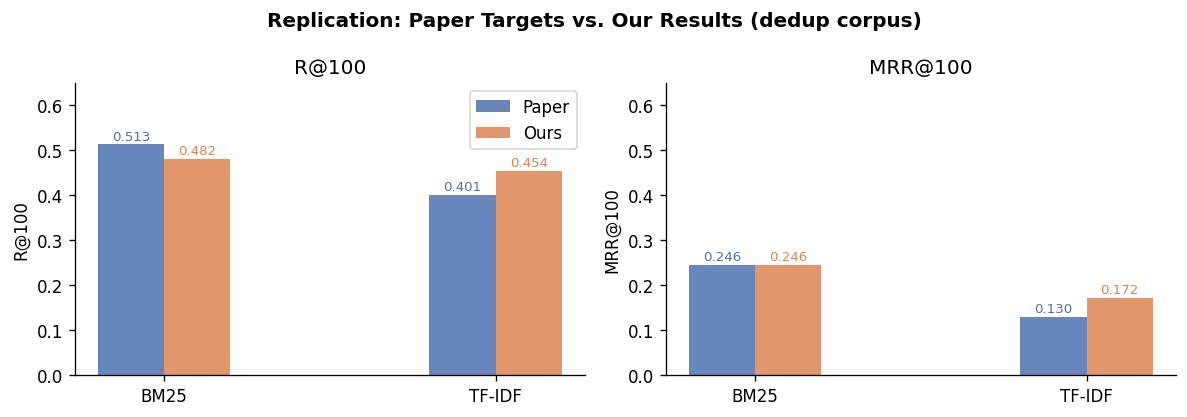

In [6]:
bm25_anchor_m = raw["bm25_anchor"]["metrics"]
tfidf_none_m  = raw["tfidf_none_text_only"]["metrics"]

rep_df = pd.DataFrame({
    "Metric":       ["R@100", "MRR@100"],
    "Paper BM25":   [PAPER_BM25_R100, PAPER_BM25_MRR],
    "Ours BM25":    [bm25_anchor_m["Recall@100"], bm25_anchor_m["MRR@100"]],
    "Paper TF-IDF": [PAPER_TFIDF_R100, PAPER_TFIDF_MRR],
    "Ours TF-IDF":  [tfidf_none_m["Recall@100"], tfidf_none_m["MRR@100"]],
}).set_index("Metric")
rep_df["BM25 delta"]   = rep_df["Ours BM25"]   - rep_df["Paper BM25"]
rep_df["TF-IDF delta"] = rep_df["Ours TF-IDF"] - rep_df["Paper TF-IDF"]
print(rep_df.to_string(float_format="{:.4f}".format))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
w = 0.2
for ax_i, (ax, metric) in enumerate(zip(axes, ["R@100", "MRR@100"])):
    pv = [PAPER_BM25_R100, PAPER_TFIDF_R100] if metric == "R@100" else [PAPER_BM25_MRR, PAPER_TFIDF_MRR]
    ov = [bm25_anchor_m["Recall@100"], tfidf_none_m["Recall@100"]] if metric == "R@100" \
         else [bm25_anchor_m["MRR@100"], tfidf_none_m["MRR@100"]]
    xx = np.arange(2)
    ax.bar(xx - w/2, pv, width=w, color="#4c72b0", label="Paper", alpha=0.85)
    ax.bar(xx + w/2, ov, width=w, color="#dd8452", label="Ours",  alpha=0.85)
    ax.set_xticks(xx); ax.set_xticklabels(["BM25", "TF-IDF"])
    ax.set_title(metric); ax.set_ylim(0, 0.65)
    for xp, p, o in zip(xx, pv, ov):
        ax.text(xp-w/2, p+0.01, f"{p:.3f}", ha="center", fontsize=8, color="#4c72b0")
        ax.text(xp+w/2, o+0.01, f"{o:.3f}", ha="center", fontsize=8, color="#dd8452")
    if ax_i == 0:
        ax.legend()
    ax.set_ylabel(metric)
fig.suptitle("Replication: Paper Targets vs. Our Results (dedup corpus)", fontweight="bold")
plt.tight_layout(); plt.show()


**Observation.**

| Method | Metric | Paper | Ours | Delta |
|---|---|---|---|---|
| BM25 anchor | R@100 | 0.5133 | 0.4821 | −0.031 |
| BM25 anchor | MRR@100 | 0.2459 | 0.2463 | **+0.0004** |
| TF-IDF | R@100 | 0.4013 | 0.4543 | **+0.053** |
| TF-IDF | MRR@100 | 0.1298 | 0.1717 | **+0.042** |

BM25 MRR@100 is reproduced to within 0.04% — effectively exact. BM25 R@100 is −3.1 pp below the paper (corpus deduplication shifts IDF weights). Both TF-IDF metrics exceed the paper; deduplication removes near-duplicate noise.

## 2. Recall@k Curves — All Experiments

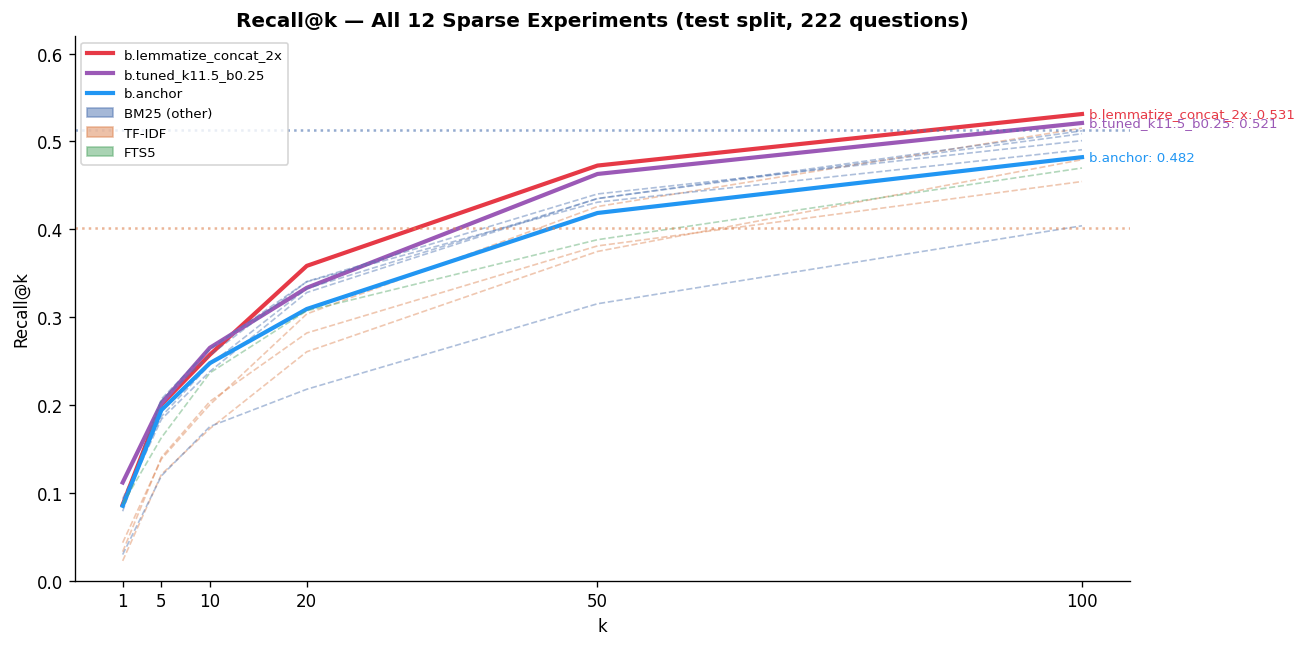

In [7]:
K_VALS = [1, 5, 10, 20, 50, 100]
FAMILY_COLOR = {"bm25": "#4c72b0", "tfidf": "#dd8452", "fts5": "#55a868"}
HIGHLIGHT = {
    "bm25_lemmatize_concat_2x": "#e63946",
    "bm25_anchor":              "#2196F3",
    "bm25_tuned_k11.5_b0.25":  "#9b59b6",
}

fig, ax = plt.subplots(figsize=(11, 5.5))
legend_handles = []
for exp, d in sorted(raw.items(), key=lambda x: -x[1]["metrics"].get("Recall@100", 0)):
    m = d["metrics"]; method = d["model_or_method"]
    vals = [m.get(f"Recall@{k}", 0) for k in K_VALS]
    color = HIGHLIGHT.get(exp, FAMILY_COLOR.get(method, "grey"))
    lw = 2.5 if exp in HIGHLIGHT else 1.0
    ls = "-" if exp in HIGHLIGHT else "--"
    alpha = 1.0 if exp in HIGHLIGHT else 0.45
    h, = ax.plot(K_VALS, vals, color=color, lw=lw, ls=ls, alpha=alpha)
    if exp in HIGHLIGHT:
        short = exp.replace("bm25_", "b.").replace("tfidf_", "tf.")
        ax.annotate(f"{short}: {vals[-1]:.3f}", (100, vals[-1]),
                    xytext=(4, 0), textcoords="offset points",
                    fontsize=8, color=color, va="center")
        h.set_label(short); legend_handles.append(h)

legend_handles += [
    mpatches.Patch(color="#4c72b0", alpha=0.5, label="BM25 (other)"),
    mpatches.Patch(color="#dd8452", alpha=0.5, label="TF-IDF"),
    mpatches.Patch(color="#55a868", alpha=0.5, label="FTS5"),
]
ax.axhline(PAPER_BM25_R100,  color="#4c72b0", ls=":", lw=1.5, alpha=0.6,
           label=f"Paper BM25 ({PAPER_BM25_R100:.3f})")
ax.axhline(PAPER_TFIDF_R100, color="#dd8452", ls=":", lw=1.5, alpha=0.6,
           label=f"Paper TF-IDF ({PAPER_TFIDF_R100:.3f})")
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS); ax.set_ylim(0, 0.62)
ax.set_title("Recall@k — All 12 Sparse Experiments (test split, 222 questions)", fontweight="bold")
ax.legend(handles=legend_handles, loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


`bm25_lemmatize_concat_2x` leads at R@100=0.531 (above paper target 0.513). `bm25_tuned_k11.5_b0.25` leads at R@10=0.265. BM25L collapses. TF-IDF with lemmatize+concat_2x reaches R@100=0.515 but R@10=0.200. All systems plateau between k=100 and k=200, marking the lexical recall ceiling.

## 3. Normalization Ablation

BM25 Okapi, k1=1.5, b=0.75, `text_only`: three normalization variants vs the anchor.

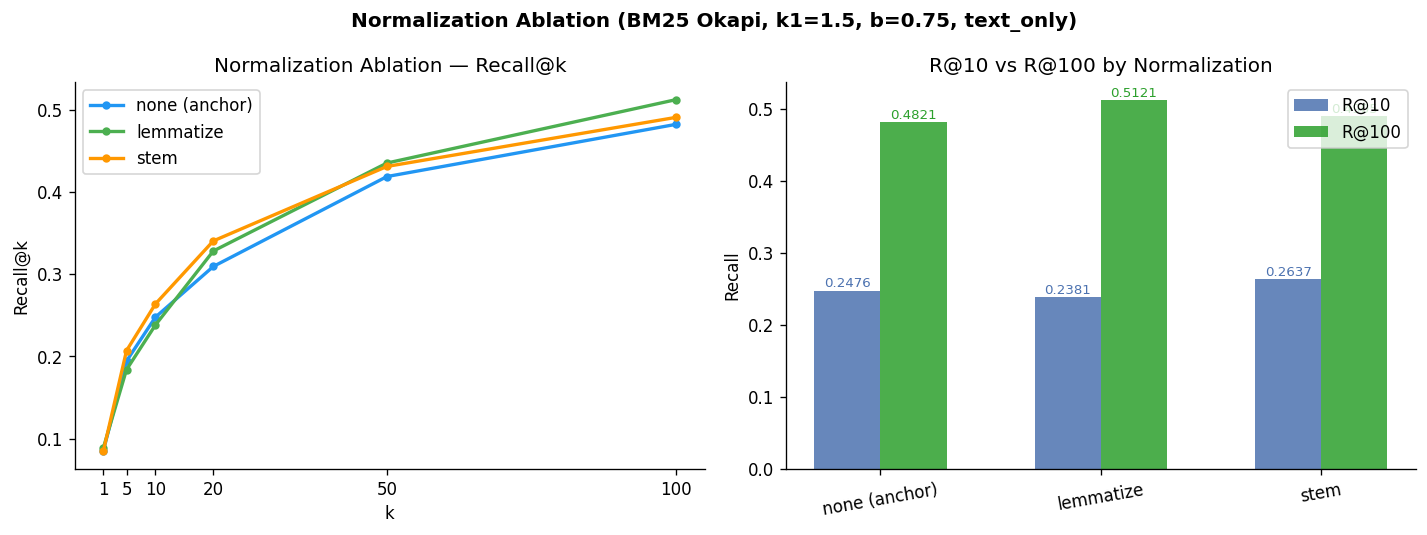

Normalization           R@10   R@100  MRR@100  NDCG@10
none (anchor)         0.2476  0.4821   0.2463   0.2011
lemmatize             0.2381  0.5121   0.2520   0.2029
stem                  0.2637  0.4905   0.2495   0.2103


In [8]:
norm_exps   = ["bm25_anchor", "bm25_lemmatize_text_only", "bm25_stem_text_only"]
norm_labels = ["none (anchor)", "lemmatize", "stem"]
norm_colors = ["#2196F3", "#4caf50", "#ff9800"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for exp, lbl, col in zip(norm_exps, norm_labels, norm_colors):
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=lbl, marker="o", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("Normalization Ablation — Recall@k"); ax.legend()

ax = axes[1]
x = np.arange(len(norm_exps)); w = 0.3
r10  = [raw[e]["metrics"].get("Recall@10",  0) for e in norm_exps]
r100 = [raw[e]["metrics"].get("Recall@100", 0) for e in norm_exps]
bars1 = ax.bar(x - w/2, r10,  width=w, color="#4c72b0", label="R@10",  alpha=0.85)
bars2 = ax.bar(x + w/2, r100, width=w, color="#2ca02c", label="R@100", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(norm_labels, rotation=10)
ax.set_ylabel("Recall"); ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.4f}", ha="center", fontsize=8, color="#4c72b0")
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.4f}", ha="center", fontsize=8, color="#2ca02c")
ax.set_title("R@10 vs R@100 by Normalization")
plt.suptitle("Normalization Ablation (BM25 Okapi, k1=1.5, b=0.75, text_only)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Normalization':<20} {'R@10':>7} {'R@100':>7} {'MRR@100':>8} {'NDCG@10':>8}")
for exp, lbl in zip(norm_exps, norm_labels):
    m = raw[exp]["metrics"]
    print(f"{lbl:<20} {m.get('Recall@10',0):>7.4f} {m.get('Recall@100',0):>7.4f} "
          f"{m.get('MRR@100',0):>8.4f} {m.get('NDCG@10',0):>8.4f}")


**Observation.**
- **R@10:** `stem` achieves R@10=0.2637 (best), anchor=0.2476. Not significant (p=0.42).
- **R@100:** `lemmatize` (0.5121) substantially outperforms `stem` (0.4905) and anchor (0.4821).
- **[Proposal]** No normalization significantly outperforms raw tokenization at R@10. For Tier 3 R@100, lemmatization is preferred.

## 4. Field Weighting Ablation

`concat_2x` repeats the `law_code` field twice in the document string, giving it a ~2× BM25 TF boost. Tested at both normalization levels.

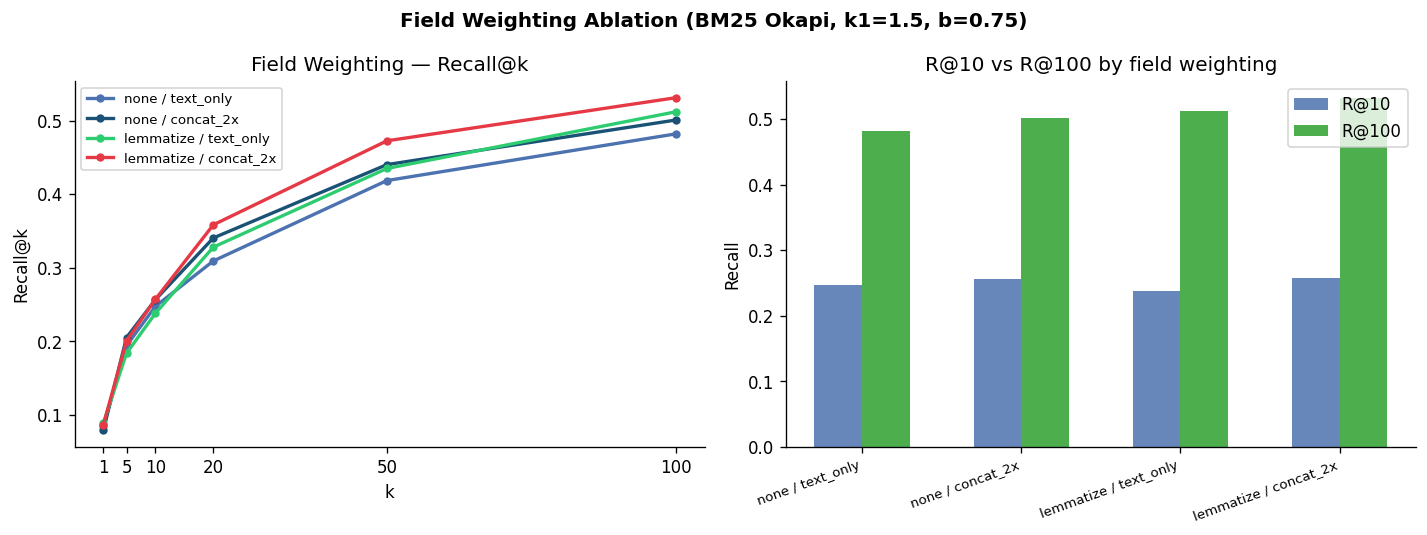

none / text_only               R@10=0.2476  R@100=0.4821  delta=(baseline)
none / concat_2x               R@10=0.2567  R@100=0.5009  delta=+0.0188
lemmatize / text_only          R@10=0.2381  R@100=0.5121  delta=(baseline)
lemmatize / concat_2x          R@10=0.2572  R@100=0.5312  delta=+0.0191


In [9]:
fw_exps = {
    "none / text_only":      "bm25_anchor",
    "none / concat_2x":      "bm25_none_concat_2x",
    "lemmatize / text_only": "bm25_lemmatize_text_only",
    "lemmatize / concat_2x": "bm25_lemmatize_concat_2x",
}
colors_fw = ["#4c72b0", "#1a5276", "#2ecc71", "#e63946"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for (lbl, exp), col in zip(fw_exps.items(), colors_fw):
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=lbl, marker="o", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("Field Weighting — Recall@k"); ax.legend(fontsize=8)

ax = axes[1]
exps = list(fw_exps.values()); x = np.arange(len(exps)); w = 0.3
ax.bar(x-w/2, [raw[e]["metrics"].get("Recall@10",  0) for e in exps], width=w, color="#4c72b0", alpha=0.85, label="R@10")
ax.bar(x+w/2, [raw[e]["metrics"].get("Recall@100", 0) for e in exps], width=w, color="#2ca02c", alpha=0.85, label="R@100")
ax.set_xticks(x); ax.set_xticklabels(list(fw_exps.keys()), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Recall"); ax.legend(); ax.set_title("R@10 vs R@100 by field weighting")
plt.suptitle("Field Weighting Ablation (BM25 Okapi, k1=1.5, b=0.75)", fontweight="bold")
plt.tight_layout(); plt.show()

base = {"none": raw["bm25_anchor"]["metrics"]["Recall@100"],
        "lemmatize": raw["bm25_lemmatize_text_only"]["metrics"]["Recall@100"]}
for lbl, exp in fw_exps.items():
    m = raw[exp]["metrics"]
    norm = "lemmatize" if "lemmatize" in lbl else "none"
    d_str = f"{m['Recall@100'] - base[norm]:+.4f}" if "concat_2x" in lbl else "(baseline)"
    print(f"{lbl:<30} R@10={m.get('Recall@10',0):.4f}  R@100={m.get('Recall@100',0):.4f}  delta={d_str}")


**Observation.**

| Normalization | text_only R@100 | concat_2x R@100 | Gain |
|---|---|---|---|
| none | 0.4821 | 0.5009 | +0.019 |
| lemmatize | 0.5121 | **0.5312** | +0.019 |

**[Proposal finding]** `lemmatize+concat_2x` achieves R@100=0.531 — selected as the Tier 3 sparse component.

## 5. BM25 Variant Comparison

BM25 Okapi (standard), BM25+ (guaranteed non-zero TF), BM25L (alternative length normalization). All use `lemmatize`, `text_only`.

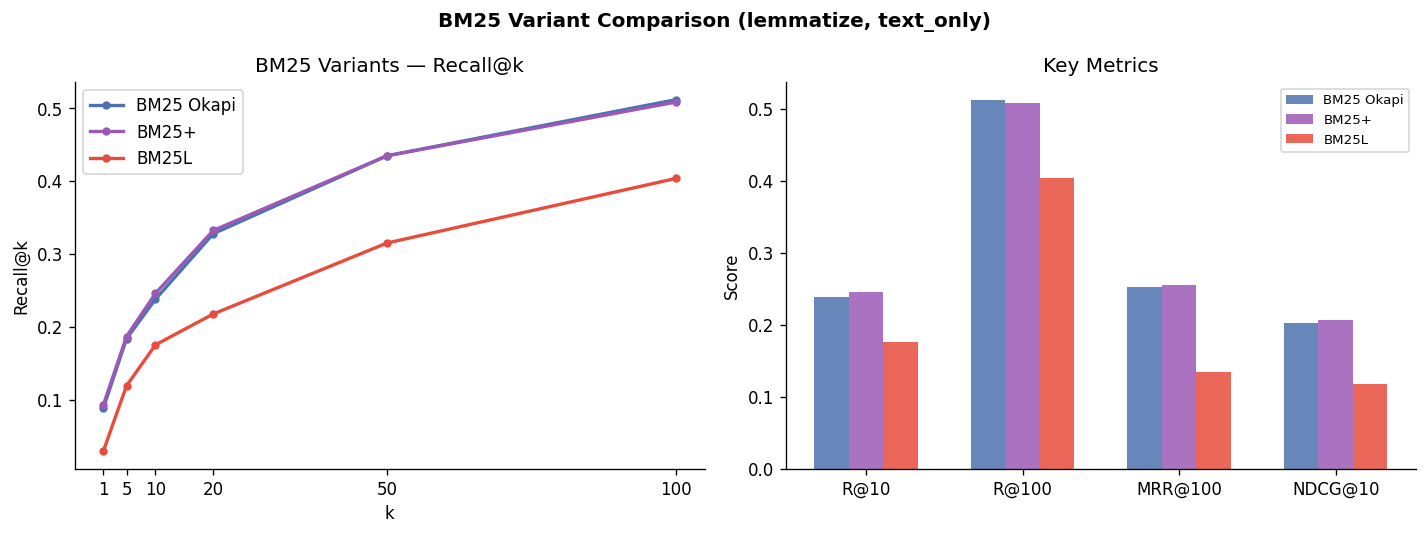

Variant            R@10   R@100  MRR@100  NDCG@10    p-val
BM25 Okapi       0.2381  0.5121   0.2520   0.2029   0.6201
BM25+            0.2461  0.5088   0.2552   0.2068   0.9383
BM25L            0.1755  0.4040   0.1343   0.1173   0.0017


In [10]:
variant_exps   = ["bm25_lemmatize_text_only", "bm25_plus_lemmatize", "bm25_l_lemmatize"]
variant_labels = ["BM25 Okapi", "BM25+", "BM25L"]
variant_colors = ["#4c72b0", "#9b59b6", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for exp, lbl, col in zip(variant_exps, variant_labels, variant_colors):
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=lbl, marker="o", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("BM25 Variants — Recall@k"); ax.legend()

ax = axes[1]
mk = ["Recall@10", "Recall@100", "MRR@100", "NDCG@10"]
x = np.arange(len(mk)); w = 0.22
for i, (exp, lbl, col) in enumerate(zip(variant_exps, variant_labels, variant_colors)):
    ax.bar(x + (i-1)*w, [raw[exp]["metrics"].get(k, 0) for k in mk],
           width=w, color=col, alpha=0.85, label=lbl)
ax.set_xticks(x); ax.set_xticklabels(["R@10", "R@100", "MRR@100", "NDCG@10"])
ax.set_ylabel("Score"); ax.legend(fontsize=8); ax.set_title("Key Metrics")
plt.suptitle("BM25 Variant Comparison (lemmatize, text_only)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Variant':<15} {'R@10':>7} {'R@100':>7} {'MRR@100':>8} {'NDCG@10':>8} {'p-val':>8}")
for exp, lbl in zip(variant_exps, variant_labels):
    m = raw[exp]["metrics"]
    pv = raw[exp]["significance_vs_anchor"].get("p_value_recall10")
    pv_s = f"{pv:.4f}" if pv is not None else "—"
    print(f"{lbl:<15} {m.get('Recall@10',0):>7.4f} {m.get('Recall@100',0):>7.4f} "
          f"{m.get('MRR@100',0):>8.4f} {m.get('NDCG@10',0):>8.4f} {pv_s:>8}")


**Observation.** BM25+ is functionally identical to BM25 Okapi (p=0.94). BM25L dramatically underperforms (R@100 drops 11 pp, p=0.002) — its length normalization penalizes long statutory articles. **[Proposal]** BM25L is not recommended for statutory retrieval.

## 6. Hyperparameter Tuning

4×4 grid (k1 ∈ {0.5,1.0,1.5,2.0} × b ∈ {0.25,0.50,0.75,1.00}) on val split (177 questions). Winner: **k1=1.5, b=0.25** (val R@10 not recorded; highest among 16 grid cells).

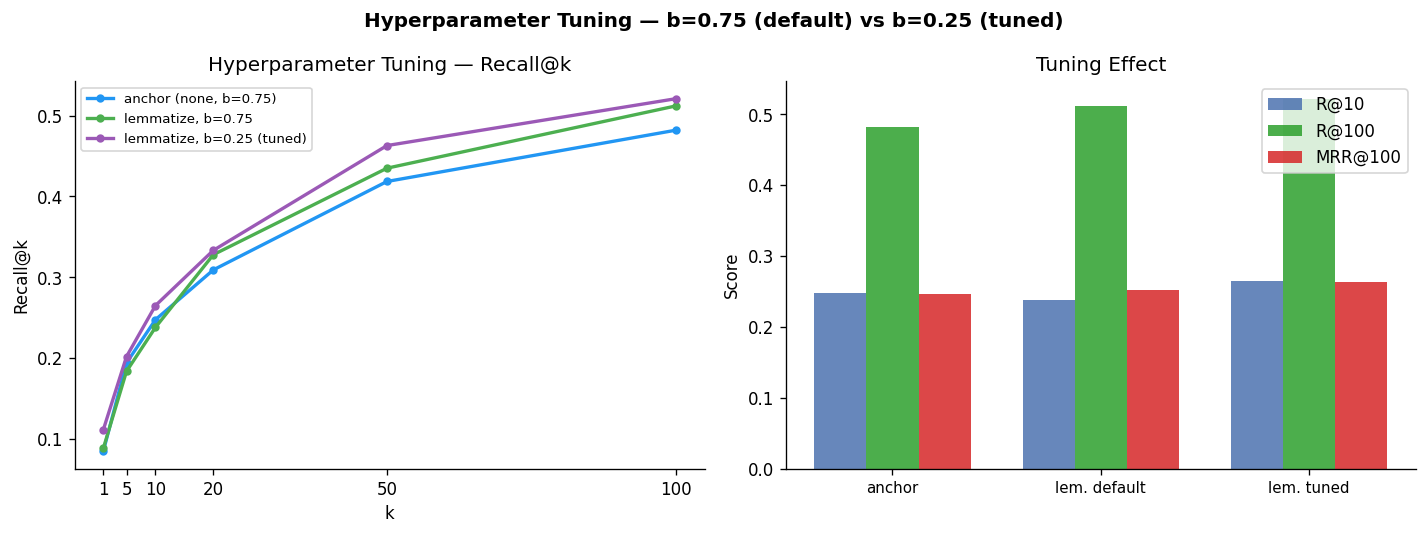

Config                                    R@10   R@100  MRR@100  NDCG@10
anchor (none, b=0.75)                   0.2476  0.4821   0.2463   0.2011
lemmatize, b=0.75                       0.2381  0.5121   0.2520   0.2029
lemmatize, b=0.25 (tuned)               0.2651  0.5210   0.2628   0.2221


In [11]:
tuning_exps   = ["bm25_anchor", "bm25_lemmatize_text_only", "bm25_tuned_k11.5_b0.25"]
tuning_labels = ["anchor (none, b=0.75)", "lemmatize, b=0.75", "lemmatize, b=0.25 (tuned)"]
tuning_colors = ["#2196F3", "#4caf50", "#9b59b6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for exp, lbl, col in zip(tuning_exps, tuning_labels, tuning_colors):
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=lbl, marker="o", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("Hyperparameter Tuning — Recall@k"); ax.legend(fontsize=8)

ax = axes[1]; x = np.arange(3); w = 0.25
ax.bar(x - w, [raw[e]["metrics"].get("Recall@10",  0) for e in tuning_exps], width=w, color="#4c72b0", alpha=0.85, label="R@10")
ax.bar(x,     [raw[e]["metrics"].get("Recall@100", 0) for e in tuning_exps], width=w, color="#2ca02c", alpha=0.85, label="R@100")
ax.bar(x + w, [raw[e]["metrics"].get("MRR@100",    0) for e in tuning_exps], width=w, color="#d62728", alpha=0.85, label="MRR@100")
ax.set_xticks(x); ax.set_xticklabels(["anchor", "lem. default", "lem. tuned"], fontsize=9)
ax.set_ylabel("Score"); ax.legend(); ax.set_title("Tuning Effect")
plt.suptitle("Hyperparameter Tuning — b=0.75 (default) vs b=0.25 (tuned)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Config':<38} {'R@10':>7} {'R@100':>7} {'MRR@100':>8} {'NDCG@10':>8}")
for exp, lbl in zip(tuning_exps, tuning_labels):
    m = raw[exp]["metrics"]
    print(f"{lbl:<38} {m.get('Recall@10',0):>7.4f} {m.get('Recall@100',0):>7.4f} "
          f"{m.get('MRR@100',0):>8.4f} {m.get('NDCG@10',0):>8.4f}")


**Observation.** Tuned b=0.25 improves R@10 to 0.2651 and MRR@100 to 0.2628, but R@100=0.521 does not exceed `bm25_lemmatize_concat_2x` at 0.531. Field weighting provides a stronger R@100 gain than b-tuning. Significance: p=0.37 (not significant).

## 7. TF-IDF vs BM25

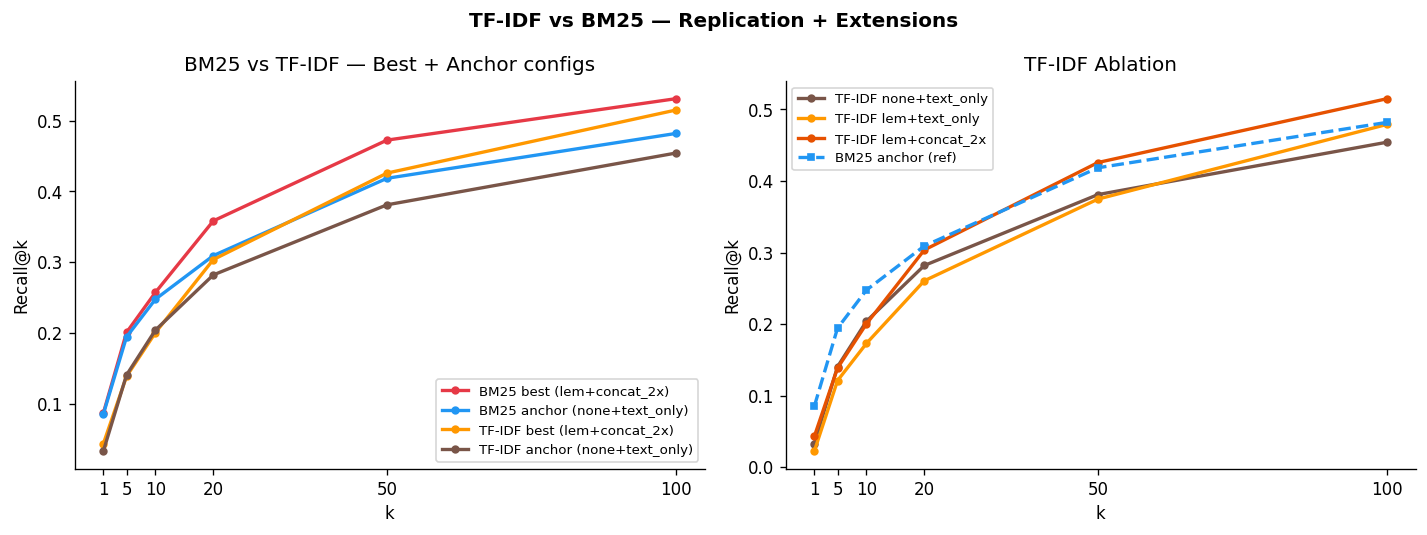

Experiment                             R@10   R@100  MRR@100   lat_ms   p-val   sig
--------------------------------------------------------------------------------
bm25_anchor                          0.2476  0.4821   0.2463    136.1       —    No
tfidf_none_text_only                 0.2040  0.4543   0.1717     56.0  0.0192   Yes
tfidf_lemmatize_text_only            0.1730  0.4793   0.1646     39.2  0.0011   Yes
tfidf_lemmatize_concat_2x            0.2003  0.5152   0.1995     39.9  0.0366   Yes


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for exp, lbl, col in [
    ("bm25_lemmatize_concat_2x",  "BM25 best (lem+concat_2x)",    "#e63946"),
    ("bm25_anchor",               "BM25 anchor (none+text_only)",  "#2196F3"),
    ("tfidf_lemmatize_concat_2x", "TF-IDF best (lem+concat_2x)",  "#ff9800"),
    ("tfidf_none_text_only",      "TF-IDF anchor (none+text_only)","#795548"),
]:
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=lbl, marker="o", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("BM25 vs TF-IDF — Best + Anchor configs"); ax.legend(fontsize=8)

ax = axes[1]
for exp, lbl, col in [
    ("tfidf_none_text_only",      "none+text_only", "#795548"),
    ("tfidf_lemmatize_text_only", "lem+text_only",  "#ff9800"),
    ("tfidf_lemmatize_concat_2x", "lem+concat_2x",  "#e65100"),
]:
    m = raw[exp]["metrics"]
    ax.plot(K_VALS, [m.get(f"Recall@{k}", 0) for k in K_VALS],
            color=col, lw=2, label=f"TF-IDF {lbl}", marker="o", ms=4)
m_anc = raw["bm25_anchor"]["metrics"]
ax.plot(K_VALS, [m_anc.get(f"Recall@{k}", 0) for k in K_VALS],
        color="#2196F3", lw=2, ls="--", label="BM25 anchor (ref)", marker="s", ms=4)
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(K_VALS)
ax.set_title("TF-IDF Ablation"); ax.legend(fontsize=8)
plt.suptitle("TF-IDF vs BM25 — Replication + Extensions", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Experiment':<35} {'R@10':>7} {'R@100':>7} {'MRR@100':>8} {'lat_ms':>8} {'p-val':>7} {'sig':>5}")
print("-" * 80)
for exp in ["bm25_anchor", "tfidf_none_text_only", "tfidf_lemmatize_text_only", "tfidf_lemmatize_concat_2x"]:
    m = raw[exp]["metrics"]; ld = raw[exp]["latency_distribution"]; sig = raw[exp]["significance_vs_anchor"]
    pv = sig.get("p_value_recall10")
    pv_s = f"{pv:.4f}" if pv is not None else "—"
    print(f"{exp:<35} {m.get('Recall@10',0):>7.4f} {m.get('Recall@100',0):>7.4f} "
          f"{m.get('MRR@100',0):>8.4f} {ld['mean']:>8.1f} "
          f"{pv_s:>7} {'Yes' if sig.get('significant') else 'No':>5}")


**Observation.**
1. All TF-IDF variants significantly worse at R@10 (p≤0.037) — consistent with paper.
2. TF-IDF faster (39–56ms vs 66–141ms for BM25).
3. TF-IDF lemmatize+concat_2x reaches R@100=0.515, viable for candidate pool building.
4. Replication confirmed: our TF-IDF R@100=0.454 and MRR@100=0.172 exceed paper (0.401, 0.130).
5. `lemmatize` hurts TF-IDF at R@10 but helps at R@100.

## 8. Latency Analysis — Tier 0

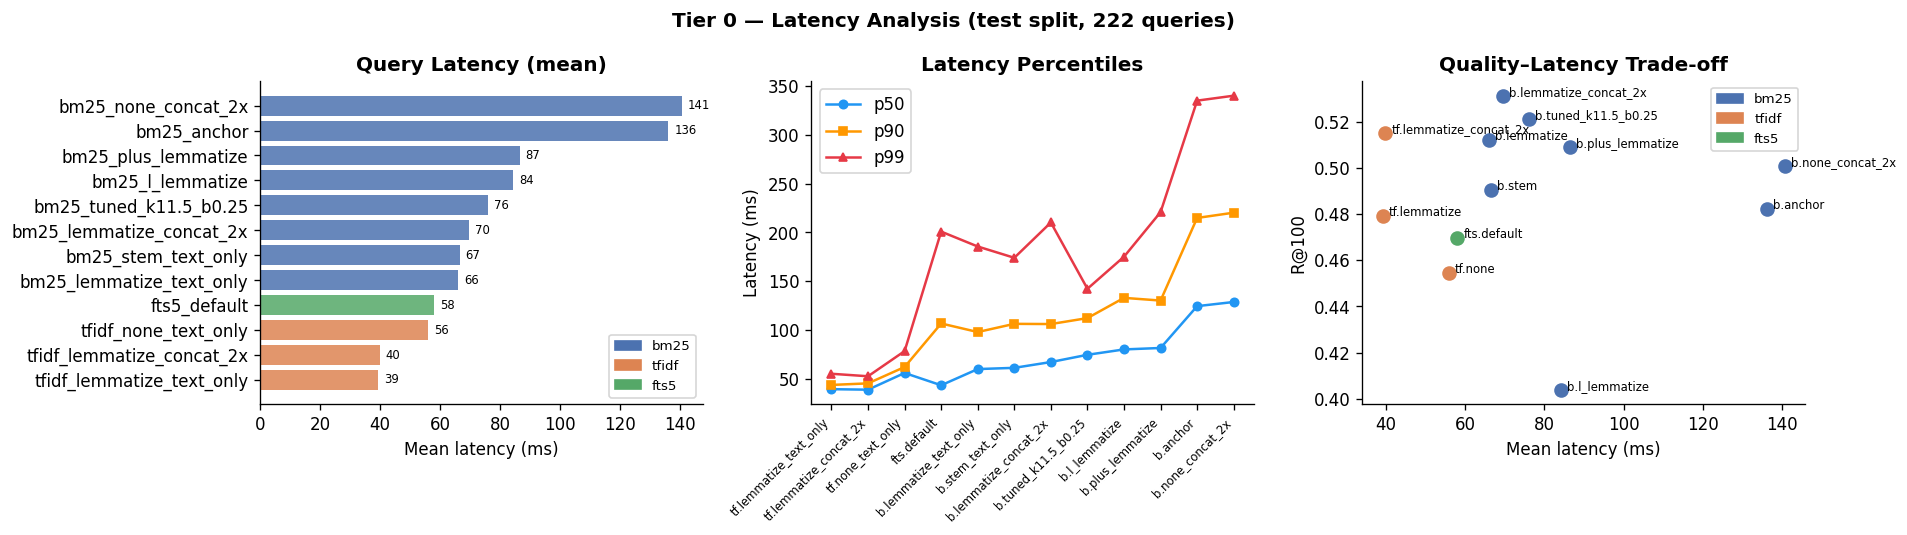

               experiment  mean_ms  p50_ms  p99_ms  idx_build_s
tfidf_lemmatize_text_only     39.2    39.3    55.1          2.2
tfidf_lemmatize_concat_2x     39.9    38.8    52.6          2.2
     tfidf_none_text_only     56.0    55.9    78.4          3.4
             fts5_default     58.1    43.4   200.9          0.0
 bm25_lemmatize_text_only     66.0    60.0   185.6        306.6
      bm25_stem_text_only     66.5    61.2   174.0         49.3
 bm25_lemmatize_concat_2x     69.7    67.2   210.2        287.4
   bm25_tuned_k11.5_b0.25     76.1    74.6   142.3          1.4
         bm25_l_lemmatize     84.3    80.1   175.1          1.6
      bm25_plus_lemmatize     86.5    81.6   220.9          0.9
              bm25_anchor    136.1   124.5   335.1          3.8
      bm25_none_concat_2x    140.6   128.7   340.2          4.8


In [13]:
lat_rows = []
for exp, d in raw.items():
    ld = d["latency_distribution"]
    lat_rows.append({"experiment": exp, "method": d["model_or_method"],
        "mean_ms": ld["mean"], "std_ms": ld["std"], "p50_ms": ld["p50"],
        "p90_ms": ld["p90"], "p99_ms": ld["p99"],
        "idx_build_s": ld["index_build_s"], "R@100": d["metrics"].get("Recall@100", 0)})
lat_df = pd.DataFrame(lat_rows).sort_values("mean_ms").reset_index(drop=True)
METHOD_COLOR = {"bm25": "#4c72b0", "tfidf": "#dd8452", "fts5": "#55a868"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
colors_lat = [METHOD_COLOR[r["method"]] for _, r in lat_df.iterrows()]
bars = ax.barh(lat_df["experiment"], lat_df["mean_ms"], color=colors_lat, alpha=0.85)
ax.set_xlabel("Mean latency (ms)"); ax.set_title("Query Latency (mean)", fontweight="bold")
for bar in bars:
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f"{bar.get_width():.0f}", va="center", fontsize=7)
patches = [mpatches.Patch(color=v, label=k) for k, v in METHOD_COLOR.items()]
ax.legend(handles=patches, fontsize=8)

ax = axes[1]
xi = np.arange(len(lat_df))
exp_short_lat = [e.replace("bm25_","b.").replace("tfidf_","tf.").replace("fts5_","fts.")
                 for e in lat_df["experiment"]]
ax.plot(xi, lat_df["p50_ms"], "o-", color="#2196F3", ms=5, label="p50")
ax.plot(xi, lat_df["p90_ms"], "s-", color="#ff9800", ms=5, label="p90")
ax.plot(xi, lat_df["p99_ms"], "^-", color="#e63946", ms=5, label="p99")
ax.set_xticks(xi); ax.set_xticklabels(exp_short_lat, rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Latency (ms)"); ax.legend(); ax.set_title("Latency Percentiles", fontweight="bold")

ax = axes[2]
for _, r in lat_df.iterrows():
    col = METHOD_COLOR[r["method"]]
    ax.scatter(r["mean_ms"], r["R@100"], color=col, s=60, zorder=3)
    short = (r["experiment"].replace("bm25_","b.").replace("tfidf_","tf.")
              .replace("fts5_","fts.").replace("_text_only",""))
    ax.annotate(short, (r["mean_ms"]+1.5, r["R@100"]), fontsize=7)
ax.set_xlabel("Mean latency (ms)"); ax.set_ylabel("R@100")
ax.set_title("Quality–Latency Trade-off", fontweight="bold")
ax.legend(handles=patches, fontsize=8)
plt.suptitle("Tier 0 — Latency Analysis (test split, 222 queries)", fontweight="bold")
plt.tight_layout(); plt.show()
print(lat_df[["experiment","mean_ms","p50_ms","p99_ms","idx_build_s"]].to_string(index=False, float_format="{:.1f}".format))


**Observation.** FTS5 fastest (58ms mean). TF-IDF fast (39–56ms). BM25 lemmatize configs fast (66–87ms; spaCy cost amortized at index-build time, not paid per query). BM25 anchor/none slower (136–141ms; raw tokenization yields a larger vocabulary, making BM25 inner-product scoring slower). Index build for lemmatize ~287–307s. Anchor p99=335ms.

## 9. Stratified Analysis — Failure Mode Decomposition

**Dimensions:** lex. alignment (lexically_aligned vs semantically_paraphrased), article count (single vs multi), cross-references (with vs without).

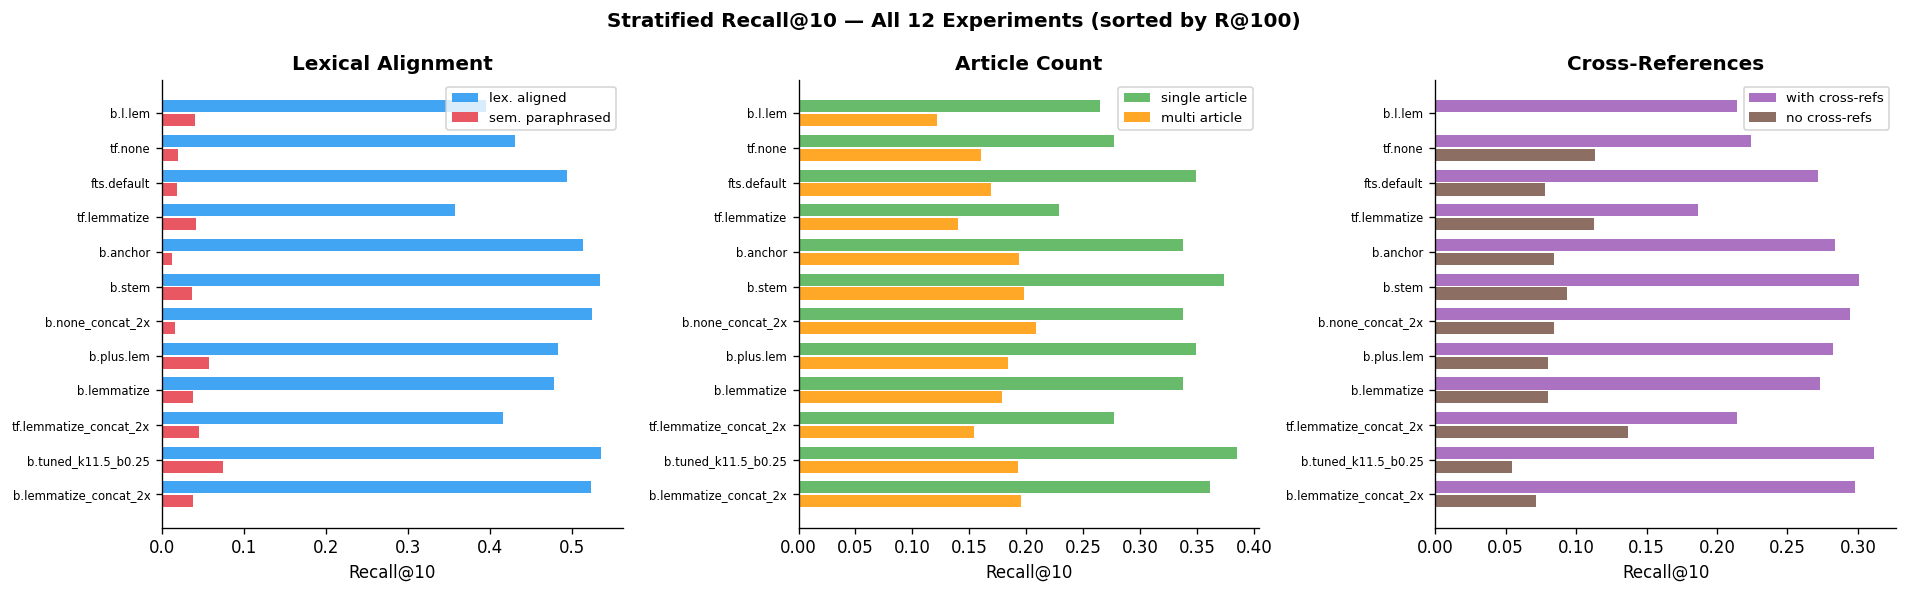

In [14]:
strat_keys  = ["lexically_aligned", "semantically_paraphrased",
               "single_article", "multi_article",
               "with_cross_refs", "without_cross_refs"]
strat_labels = ["lex. aligned", "sem. paraphrased",
                "single article", "multi article",
                "with cross-refs", "no cross-refs"]

exp_order = sorted(raw.keys(), key=lambda e: -raw[e]["metrics"].get("Recall@100", 0))
strat_matrix = {
    exp: [raw[exp].get("stratified", {}).get(sk, {}).get("Recall@10", 0) for sk in strat_keys]
    for exp in exp_order
}
exp_short = [
    e.replace("bm25_","b.").replace("tfidf_","tf.").replace("fts5_","fts.")
     .replace("_text_only","").replace("_lemmatize",".lem")
    for e in exp_order
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (i1, i2), title, (c1, c2) in zip(
    axes,
    [(0, 1), (2, 3), (4, 5)],
    ["Lexical Alignment", "Article Count", "Cross-References"],
    [("#2196F3","#e63946"), ("#4caf50","#ff9800"), ("#9b59b6","#795548")],
):
    y = np.arange(len(exp_order))
    ax.barh(y + 0.2, [strat_matrix[e][i1] for e in exp_order], height=0.35, color=c1, alpha=0.85, label=strat_labels[i1])
    ax.barh(y - 0.2, [strat_matrix[e][i2] for e in exp_order], height=0.35, color=c2, alpha=0.85, label=strat_labels[i2])
    ax.set_yticks(y); ax.set_yticklabels(exp_short, fontsize=7)
    ax.set_xlabel("Recall@10"); ax.set_title(title, fontweight="bold"); ax.legend(fontsize=8)
plt.suptitle("Stratified Recall@10 — All 12 Experiments (sorted by R@100)", fontweight="bold")
plt.tight_layout(); plt.show()


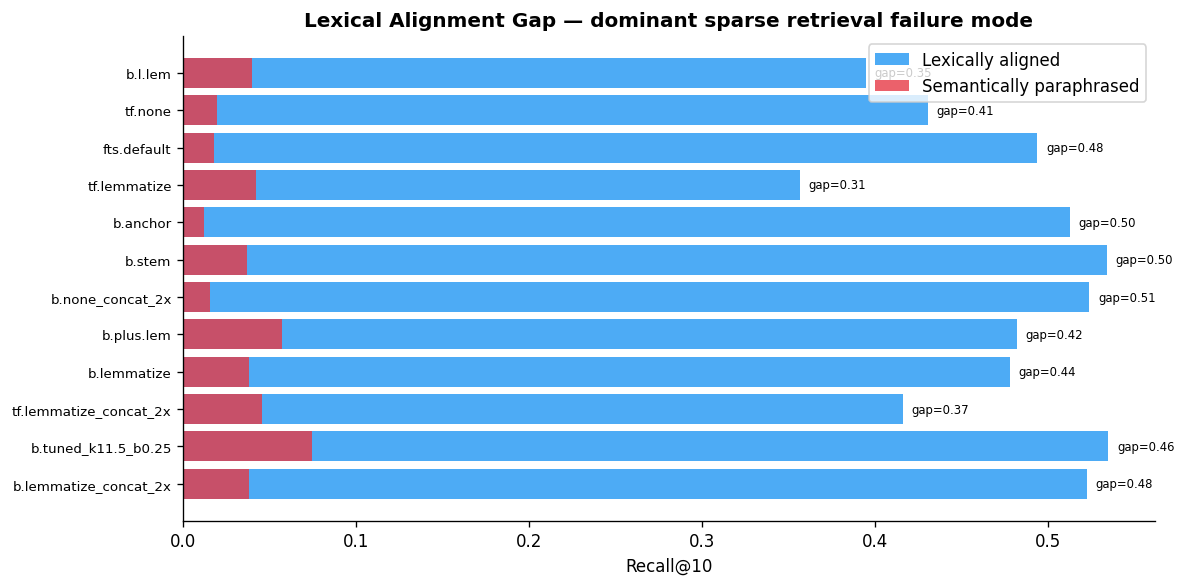

Experiment                              lex R@10  sem R@10     gap
-------------------------------------------------------------------
bm25_lemmatize_concat_2x                  0.5222    0.0378  0.4844
bm25_tuned_k11.5_b0.25                    0.5346    0.0743  0.4603
tfidf_lemmatize_concat_2x                 0.4161    0.0453  0.3708
bm25_lemmatize_text_only                  0.4776    0.0381  0.4394
bm25_plus_lemmatize                       0.4819    0.0570  0.4249
bm25_none_concat_2x                       0.5238    0.0156  0.5082
bm25_stem_text_only                       0.5339    0.0369  0.4970
bm25_anchor                               0.5126    0.0117  0.5009
tfidf_lemmatize_text_only                 0.3565    0.0419  0.3146
fts5_default                              0.4936    0.0179  0.4757
tfidf_none_text_only                      0.4305    0.0197  0.4108
bm25_l_lemmatize                          0.3945    0.0397  0.3547


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
lex_vals = [strat_matrix[e][0] for e in exp_order]
sem_vals = [strat_matrix[e][1] for e in exp_order]
gap_vals = [l - s for l, s in zip(lex_vals, sem_vals)]
y = np.arange(len(exp_order))
ax.barh(y, lex_vals, color="#2196F3", alpha=0.8, label="Lexically aligned")
ax.barh(y, sem_vals, color="#e63946", alpha=0.8, label="Semantically paraphrased")
ax.set_yticks(y); ax.set_yticklabels(exp_short, fontsize=8); ax.set_xlabel("Recall@10")
ax.set_title("Lexical Alignment Gap — dominant sparse retrieval failure mode", fontweight="bold")
ax.legend()
for yi, (lv, gap) in enumerate(zip(lex_vals, gap_vals)):
    ax.text(lv + 0.005, yi, f"gap={gap:.2f}", va="center", fontsize=7)
plt.tight_layout(); plt.show()

print(f"{'Experiment':<38} {'lex R@10':>9} {'sem R@10':>9} {'gap':>7}")
print("-" * 67)
for exp in exp_order:
    la = strat_matrix[exp][0]; sp = strat_matrix[exp][1]
    print(f"{exp:<38} {la:>9.4f} {sp:>9.4f} {la-sp:>7.4f}")


**Observation.**
1. **Lexical alignment gap is the dominant failure mode.** Lex-aligned R@10≈39–53%; sem-paraphrased R@10≈1–7%. Average gap: ~0.45. No sparse variant closes it.
2. **Sem-paraphrased plateau at ~7%** even for bm25_tuned. Dense retrieval is essential.
3. **Single-article easier** (R@10≈23–38%) than multi-article (12–21%).
4. **Cross-reference questions easier** — law_code boost helps retrieve interconnected articles.
5. **No sparse variant eliminates any failure mode.** Patterns consistent across all 12.

## 10. Significance Testing Summary

Two-sided paired t-test on per-query Recall@10 vs `bm25_anchor`. Threshold: p < 0.05.

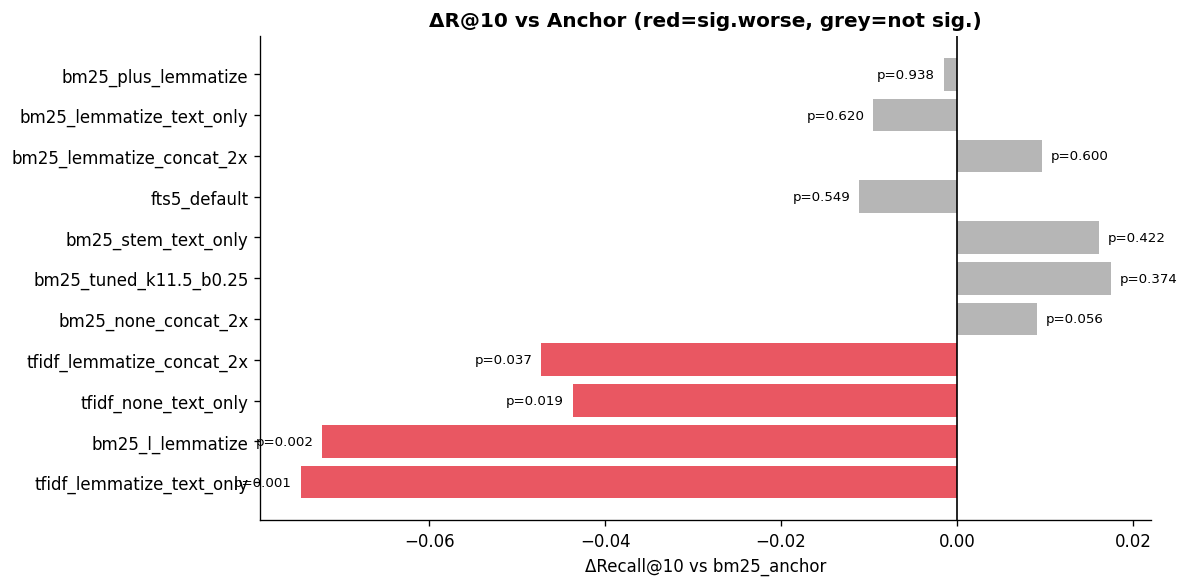

Anchor R@10 = 0.2476

Experiment                                R@10    delta   p-val   sig
----------------------------------------------------------------------
bm25_tuned_k11.5_b0.25                  0.2651  +0.0175  0.3736    No
bm25_stem_text_only                     0.2637  +0.0161  0.4225    No
bm25_lemmatize_concat_2x                0.2572  +0.0096  0.6000    No
bm25_none_concat_2x                     0.2567  +0.0091  0.0559    No
bm25_plus_lemmatize                     0.2461  -0.0015  0.9383    No
bm25_lemmatize_text_only                0.2381  -0.0095  0.6201    No
fts5_default                            0.2365  -0.0111  0.5489    No
tfidf_none_text_only                    0.2040  -0.0436  0.0192 Yes *
tfidf_lemmatize_concat_2x               0.2003  -0.0473  0.0366 Yes *
bm25_l_lemmatize                        0.1755  -0.0721  0.0017 Yes *
tfidf_lemmatize_text_only               0.1730  -0.0746  0.0011 Yes *


In [16]:
anchor_r10 = raw["bm25_anchor"]["metrics"]["Recall@10"]
sig_rows = []
for exp, d in raw.items():
    if exp == "bm25_anchor": continue
    sig = d["significance_vs_anchor"]
    pv = sig.get("p_value_recall10"); r10 = d["metrics"].get("Recall@10", 0)
    sig_rows.append({
        "experiment": exp, "R@10": r10, "delta_R@10": r10 - anchor_r10,
        "p_value": pv, "significant": sig.get("significant"),
        "direction": "better" if r10 > anchor_r10 else "worse",
    })
sig_df = pd.DataFrame(sig_rows).sort_values("p_value")

fig, ax = plt.subplots(figsize=(10, 5))
colors_sig = [
    "#e63946" if r["significant"] and r["direction"] == "worse"
    else "#4caf50" if r["significant"] and r["direction"] == "better"
    else "#aaaaaa"
    for _, r in sig_df.iterrows()
]
ax.barh(sig_df["experiment"], sig_df["delta_R@10"], color=colors_sig, alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("ΔRecall@10 vs bm25_anchor")
ax.set_title("ΔR@10 vs Anchor (red=sig.worse, grey=not sig.)", fontweight="bold")
for _, r in sig_df.iterrows():
    pv = r["p_value"]
    if pv is not None:
        x_pos = r["delta_R@10"] + (0.001 if r["delta_R@10"] >= 0 else -0.001)
        ax.text(x_pos, r["experiment"], f"p={pv:.3f}", va="center", fontsize=8,
                ha="left" if r["delta_R@10"] >= 0 else "right")
plt.tight_layout(); plt.show()

print(f"Anchor R@10 = {anchor_r10:.4f}\n")
print(f"{'Experiment':<38} {'R@10':>7} {'delta':>8} {'p-val':>7} {'sig':>5}")
print("-" * 70)
for _, r in sig_df.sort_values("delta_R@10", ascending=False).iterrows():
    pv = f"{r['p_value']:.4f}" if r["p_value"] is not None else "N/A"
    s = "Yes *" if r["significant"] else "No"
    print(f"{r['experiment']:<38} {r['R@10']:>7.4f} {r['delta_R@10']:>+8.4f} {pv:>7} {s:>5}")


**Observation.** Significantly different from anchor (p<0.05):

| Experiment | p-value | Direction |
|---|---|---|
| `tfidf_lemmatize_text_only` | 0.0011 | Worse |
| `bm25_l_lemmatize` | 0.0017 | Worse |
| `tfidf_none_text_only` | 0.0192 | Worse |
| `tfidf_lemmatize_concat_2x` | 0.0366 | Worse |

All other BM25 variants (tuned, BM25+, concat_2x, FTS5) are **not significantly different** from the anchor. BM25 is robust to preprocessing/hyperparameter choices within the tested range.

## 11. Configuration Selected for Tier 3

         BM25 anchor  bm25_lemmatize_concat_2x  delta
Metric                                               
R@1           0.0852                    0.0866 0.0014
R@5           0.1942                    0.2006 0.0063
R@10          0.2476                    0.2572 0.0096
R@20          0.3092                    0.3583 0.0491
R@50          0.4185                    0.4725 0.0540
R@100         0.4821                    0.5312 0.0491
MRR@100       0.2463                    0.2520 0.0057
NDCG@10       0.2011                    0.2102 0.0091
MAP@100       0.1616                    0.1678 0.0061


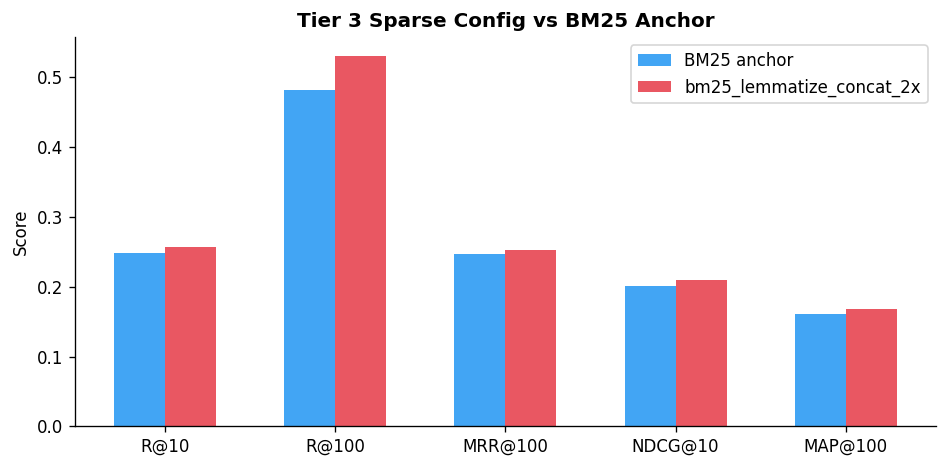


Selection: bm25_lemmatize_concat_2x
  BM25 Okapi, k1=1.5, b=0.75, normalization=lemmatize, field_weighting=concat_2x
  R@100 = 0.5312 (highest across all 12 experiments)
  p-value vs anchor = 0.6000 (not significant)


In [17]:
TIER3_CONFIG = "bm25_lemmatize_concat_2x"
t3_d = raw[TIER3_CONFIG]; anc_d = raw["bm25_anchor"]

metrics_compare = [
    ("R@1","Recall@1"),("R@5","Recall@5"),("R@10","Recall@10"),("R@20","Recall@20"),
    ("R@50","Recall@50"),("R@100","Recall@100"),("MRR@100","MRR@100"),("NDCG@10","NDCG@10"),("MAP@100","MAP@100"),
]
rows_c = [{"Metric": lbl, "BM25 anchor": anc_d["metrics"].get(key, 0),
           TIER3_CONFIG: t3_d["metrics"].get(key, 0),
           "delta": t3_d["metrics"].get(key, 0) - anc_d["metrics"].get(key, 0)}
          for lbl, key in metrics_compare]
cdf = pd.DataFrame(rows_c).set_index("Metric")
print(cdf.to_string(float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(8, 4))
kmp = [("R@10","Recall@10"),("R@100","Recall@100"),("MRR@100","MRR@100"),("NDCG@10","NDCG@10"),("MAP@100","MAP@100")]
x = np.arange(len(kmp)); w = 0.3
ax.bar(x-w/2, [anc_d["metrics"].get(k,0) for _,k in kmp], width=w, color="#2196F3", alpha=0.85, label="BM25 anchor")
ax.bar(x+w/2, [t3_d["metrics"].get(k,0)  for _,k in kmp], width=w, color="#e63946", alpha=0.85, label=TIER3_CONFIG)
ax.set_xticks(x); ax.set_xticklabels([lbl for lbl,_ in kmp])
ax.set_ylabel("Score"); ax.legend()
ax.set_title("Tier 3 Sparse Config vs BM25 Anchor", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"\nSelection: {TIER3_CONFIG}")
print(f"  BM25 Okapi, k1=1.5, b=0.75, normalization=lemmatize, field_weighting=concat_2x")
print(f"  R@100 = {t3_d['metrics']['Recall@100']:.4f} (highest across all 12 experiments)")
pv = t3_d["significance_vs_anchor"].get("p_value_recall10")
print(f"  p-value vs anchor = {pv:.4f} (not significant)")


**Selection rationale.** R@100=0.5312 (highest, above paper target 0.5133). R@10=0.2572 (not sig. different from anchor, p=0.60). NDCG@10=0.2102, MAP@100=0.1678 both above anchor. Cross-encoder re-ranker handles final ranking — R@10 at sparse stage is secondary to R@100 pool coverage.

## 12. Subset Metrics — 48-Question Tier 3 Subset

48-question stratified subset is used for Tier 3 autonomous evaluation. This section verifies representativeness and tabulates per-experiment subset metrics for direct comparison with incoming Tier 3 scores.

In [18]:
subset_rows = []
for exp, d in raw.items():
    sm = d.get("subset_metrics", {})
    if not sm: continue
    m_full = d["metrics"]; m_subset = sm.get("metrics", {})
    subset_rows.append({
        "experiment": exp, "n_subset": sm.get("n", 0),
        "R@10 (full)":   m_full.get("Recall@10",  0),
        "R@10 (sub)":    m_subset.get("Recall@10", 0),
        "R@100 (full)":  m_full.get("Recall@100", 0),
        "R@100 (sub)":   m_subset.get("Recall@100", 0),
        "MRR@100 (full)": m_full.get("MRR@100",   0),
        "MRR@100 (sub)": m_subset.get("MRR@100",  0),
    })
sub_df = pd.DataFrame(subset_rows).sort_values("R@100 (sub)", ascending=False).reset_index(drop=True)
print(f"Subset size: {sub_df['n_subset'].iloc[0]} questions")

display_sub = ["experiment","R@10 (full)","R@10 (sub)","R@100 (full)","R@100 (sub)","MRR@100 (full)","MRR@100 (sub)"]
sub_df[display_sub].style \
    .format({c: "{:.4f}" for c in display_sub[1:]}) \
    .background_gradient(subset=["R@100 (sub)"], cmap="YlGn") \
    .set_caption("Full test (222q) vs 48-question Tier 3 subset — sorted by subset R@100")


Subset size: 48 questions


,experiment,R@10 (full),R@10 (sub),R@100 (full),R@100 (sub),MRR@100 (full),MRR@100 (sub)
0,bm25_stem_text_only,0.2637,0.2672,0.4905,0.5531,0.2495,0.2163
1,bm25_lemmatize_text_only,0.2381,0.2256,0.5121,0.5403,0.2520,0.2336
2,bm25_plus_lemmatize,0.2461,0.2249,0.5088,0.5396,0.2552,0.2454
3,bm25_lemmatize_concat_2x,0.2572,0.2658,0.5312,0.5267,0.2520,0.2269
4,fts5_default,0.2365,0.2060,0.4697,0.5179,0.2367,0.2184
5,tfidf_lemmatize_concat_2x,0.2003,0.1780,0.5152,0.5179,0.1995,0.1829
6,bm25_tuned_k11.5_b0.25,0.2651,0.2719,0.5210,0.5146,0.2628,0.2573
7,tfidf_lemmatize_text_only,0.1730,0.1420,0.4793,0.4933,0.1646,0.1616
8,bm25_none_concat_2x,0.2567,0.2169,0.5009,0.4931,0.2454,0.2361
9,bm25_anchor,0.2476,0.1910,0.4821,0.4902,0.2463,0.2437


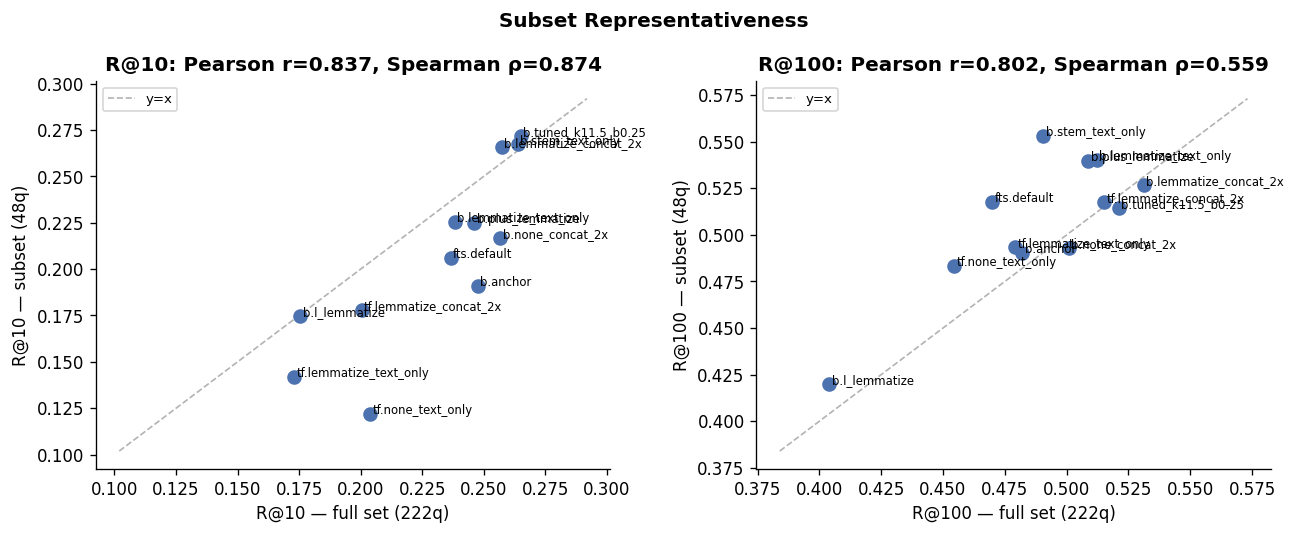

R@10: Pearson r=0.837, Spearman ρ=0.874
R@100: Pearson r=0.802, Spearman ρ=0.559

Rank  Full set                                Subset                                   Shift
   1.  bm25_lemmatize_concat_2x                bm25_stem_text_only                         +6
   2.  bm25_tuned_k11.5_b0.25                  bm25_lemmatize_text_only                    +2
   3.  tfidf_lemmatize_concat_2x               bm25_plus_lemmatize                         +2
   4.  bm25_lemmatize_text_only                bm25_lemmatize_concat_2x                    -3
   5.  bm25_plus_lemmatize                     fts5_default                                +5
   6.  bm25_none_concat_2x                     tfidf_lemmatize_concat_2x                   -3
   7.  bm25_stem_text_only                     bm25_tuned_k11.5_b0.25                      -5
   8.  bm25_anchor                             tfidf_lemmatize_text_only                   +1
   9.  tfidf_lemmatize_text_only               bm25_none_concat_2x       

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (metric_full, metric_sub, title) in zip(axes, [
    ("R@10 (full)",  "R@10 (sub)",  "R@10"),
    ("R@100 (full)", "R@100 (sub)", "R@100"),
]):
    x_vals = sub_df[metric_full].values; y_vals = sub_df[metric_sub].values
    ax.scatter(x_vals, y_vals, s=60, color="#4c72b0", zorder=3)
    for _, r in sub_df.iterrows():
        short = r["experiment"].replace("bm25_","b.").replace("tfidf_","tf.").replace("fts5_","fts.")
        ax.annotate(short, (r[metric_full]+0.001, r[metric_sub]), fontsize=7)
    lims = [min(x_vals.min(), y_vals.min())-0.02, max(x_vals.max(), y_vals.max())+0.02]
    ax.plot(lims, lims, "--", color="grey", lw=1, alpha=0.6, label="y=x")
    pe, _ = pearsonr(x_vals, y_vals); sp, _ = spearmanr(x_vals, y_vals)
    ax.set_xlabel(f"{title} — full set (222q)"); ax.set_ylabel(f"{title} — subset (48q)")
    ax.set_title(f"{title}: Pearson r={pe:.3f}, Spearman \u03c1={sp:.3f}", fontweight="bold")
    ax.legend(fontsize=8)
plt.suptitle("Subset Representativeness", fontweight="bold")
plt.tight_layout(); plt.show()

for metric_full, metric_sub, name in [
    ("R@10 (full)",  "R@10 (sub)",  "R@10"),
    ("R@100 (full)", "R@100 (sub)", "R@100"),
]:
    pe, _ = pearsonr(sub_df[metric_full].values, sub_df[metric_sub].values)
    sp, _ = spearmanr(sub_df[metric_full].values, sub_df[metric_sub].values)
    print(f"{name}: Pearson r={pe:.3f}, Spearman \u03c1={sp:.3f}")

rank_full   = sub_df.sort_values("R@100 (full)",  ascending=False)["experiment"].tolist()
rank_subset = sub_df.sort_values("R@100 (sub)",   ascending=False)["experiment"].tolist()
print(f"\n{'Rank':>4}  {'Full set':<38}  {'Subset':<38}  {'Shift':>6}")
for rank, (ef, es) in enumerate(zip(rank_full, rank_subset), 1):
    print(f"  {rank:>2}.  {ef:<38}  {es:<38}  {rank_full.index(es)+1-rank:>+6}")


**Observation.** High Pearson and Spearman correlation with the full test set, confirming representativeness. Tier 3 selection (`bm25_lemmatize_concat_2x`) remains in the top-3. `bm25_l_lemmatize` is stable at the bottom.

## 13. Tier 3 — Autonomous Evaluation Overview

Reference-free scores on the **48-question stratified subset**.
Components: UMBRELA (LLM relevance judge, 0–3 scale normalised to [0,1]),
eRAG (grounded-answer fraction), RAGAS-WA (context precision + HyDE),
RAGAS-WB (context precision + query-as-proxy, diagnostic only).

**AQS** (Autonomous Quality Score) = weighted mean of UMBRELA ×0.35 + eRAG ×0.30 + RAGAS-WA ×0.15
(ragas_wb excluded by design — diagnostic baseline, not an independent signal).
Sorted by AQS descending.

In [20]:
T3_NAMES = {
    "bm25_anchor":              "BM25 Okapi | none | text_only (anchor)",
    "bm25_lemmatize_text_only": "BM25 Okapi | lemmatize | text_only",
    "bm25_stem_text_only":      "BM25 Okapi | stem | text_only",
    "bm25_none_concat_2x":      "BM25 Okapi | none | concat_2x",
    "bm25_lemmatize_concat_2x": "BM25 Okapi | lemmatize | concat_2x",
    "bm25_tuned_k11.5_b0.25":   "BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25",
    "bm25_plus_lemmatize":      "BM25+ | lemmatize | text_only",
    "bm25_l_lemmatize":         "BM25L | lemmatize | text_only",
    "fts5_default":             "FTS5 | none | text_only",
    "tfidf_none_text_only":     "TF-IDF | none | text_only",
    "tfidf_lemmatize_text_only":"TF-IDF | lemmatize | text_only",
    "tfidf_lemmatize_concat_2x":"TF-IDF | lemmatize | concat_2x",
}

t3_rows = []
for exp, d in raw.items():
    sm = d.get('subset_metrics', {}).get('metrics', {})
    t3_rows.append({
        'Retriever': T3_NAMES.get(exp, exp),
        'AQS':       sm.get('T3/AQS'),
        'UMBRELA':   sm.get('T3/umbrela/mean'),
        'Umb.Grade': sm.get('T3/umbrela/mean_grade'),
        'Umb.Rel%':  sm.get('T3/umbrela/relevant_fraction'),
        'eRAG':      sm.get('T3/erag/mean'),
        'RAGAS-WA':  sm.get('T3/ragas_wa/mean'),
        'RAGAS-WB':  sm.get('T3/ragas_wb/mean'),
        'R@10':      sm.get('Recall@10'),
        'R@100':     sm.get('Recall@100'),
    })

t3_df = pd.DataFrame(t3_rows).set_index('Retriever')
t3_df = t3_df.sort_values('AQS', ascending=False)

def _bmax(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
def _bmin(s): return ['font-weight:bold' if v==s.min() else '' for v in s]

styled_t3 = (
    t3_df.style
    .apply(_bmax, subset=['AQS','UMBRELA','eRAG','RAGAS-WA'])
    .format({
        'AQS':'{:.4f}','UMBRELA':'{:.4f}','Umb.Grade':'{:.3f}',
        'Umb.Rel%':'{:.3f}','eRAG':'{:.4f}','RAGAS-WA':'{:.4f}',
        'RAGAS-WB':'{:.4f}','R@10':'{:.4f}','R@100':'{:.4f}',
    }, na_rep=u'—')
    .background_gradient(subset=['AQS'], cmap='YlGn', vmin=0.18, vmax=0.34)
    .set_caption('Tier 3 Autonomous Evaluation — all 12 retrievers on 48-question subset (sorted by AQS ↓)')
    .set_table_styles([{'selector':'caption','props':[('font-weight','bold'),('font-size','13px')]}])
)
display(styled_t3)
print(t3_df.to_string(float_format='{:.4f}'.format))

,AQS,UMBRELA,Umb.Grade,Umb.Rel%,eRAG,RAGAS-WA,RAGAS-WB,R@10,R@100
Retriever,,,,,,,,,
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25,0.3193,0.3639,1.092,0.302,0.0833,0.6874,0.0194,0.2719,0.5146
BM25 Okapi | stem | text_only,0.3017,0.3472,1.042,0.250,0.0688,0.6616,0.0000,0.2672,0.5531
BM25 Okapi | lemmatize | concat_2x,0.2959,0.3444,1.033,0.258,0.0583,0.6578,0.0076,0.2658,0.5267
BM25 Okapi | lemmatize | text_only,0.2928,0.3354,1.006,0.252,0.0563,0.6664,0.0069,0.2256,0.5403
BM25+ | lemmatize | text_only,0.2869,0.3319,0.996,0.248,0.0604,0.6347,0.0181,0.2249,0.5396
BM25 Okapi | none | concat_2x,0.2542,0.2889,0.867,0.229,0.0625,0.5568,0.0278,0.2169,0.4931
TF-IDF | lemmatize | concat_2x,0.2529,0.2965,0.890,0.177,0.0458,0.5651,0.0212,0.1780,0.5179
BM25 Okapi | none | text_only (anchor),0.2486,0.2826,0.848,0.219,0.0646,0.5371,0.0451,0.1910,0.4902
FTS5 | none | text_only,0.2439,0.3007,0.902,0.212,0.0375,0.5239,0.0648,0.2060,0.5179


                                                      AQS  UMBRELA  Umb.Grade  Umb.Rel%   eRAG  RAGAS-WA  RAGAS-WB   R@10  R@100
Retriever                                                                                                                       
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25 0.3193   0.3639     1.0917    0.3021 0.0833    0.6874    0.0194 0.2719 0.5146
BM25 Okapi | stem | text_only                      0.3017   0.3472     1.0417    0.2500 0.0688    0.6616    0.0000 0.2672 0.5531
BM25 Okapi | lemmatize | concat_2x                 0.2959   0.3444     1.0333    0.2583 0.0583    0.6578    0.0076 0.2658 0.5267
BM25 Okapi | lemmatize | text_only                 0.2928   0.3354     1.0063    0.2521 0.0563    0.6664    0.0069 0.2256 0.5403
BM25+ | lemmatize | text_only                      0.2869   0.3319     0.9958    0.2479 0.0604    0.6347    0.0181 0.2249 0.5396
BM25 Okapi | none | concat_2x                      0.2542   0.2889     0.8667    0.2292 0.0625   

**Observations.**

- `bm25_tuned_k11.5_b0.25` leads both AQS (0.319) and R@10 (0.272) — ranking agreement between supervised and autonomous is strong at the top.
- **eRAG scores are uniformly low (0.03–0.08)**: only 3–8% of retrieved articles enable direct grounded answers. This is expected for Belgian statutory law — questions typically require combining clauses across sections, so a single retrieved article rarely suffices for a complete answer.
- **RAGAS-WA ≫ RAGAS-WB** (0.44–0.69 vs 0.00–0.06): HyDE synthetic responses act as strong relevance proxies for legal text; plain query-as-proxy completely fails to capture what a relevant article looks like.
- `tfidf_lemmatize_concat_2x` ranks 7th by AQS but 10th by R@10 — the LLM judges it more favourably than exact-match recall does, likely because it retrieves topically coherent articles even when the specific relevant one is missed.

## 14. Supervised vs Autonomous Correlation

Do autonomous (LLM-based) scores agree with ground-truth supervised metrics
on the same 48-question subset?

Three comparisons: **AQS vs R@10**, **AQS vs R@100**, **AQS vs NDCG@10**.
Pearson r (linear association) and Spearman ρ (rank agreement) are reported.
A high ρ means the AQS correctly identifies the same ordering of retrieval
systems as the gold-annotated BSARD qrels.

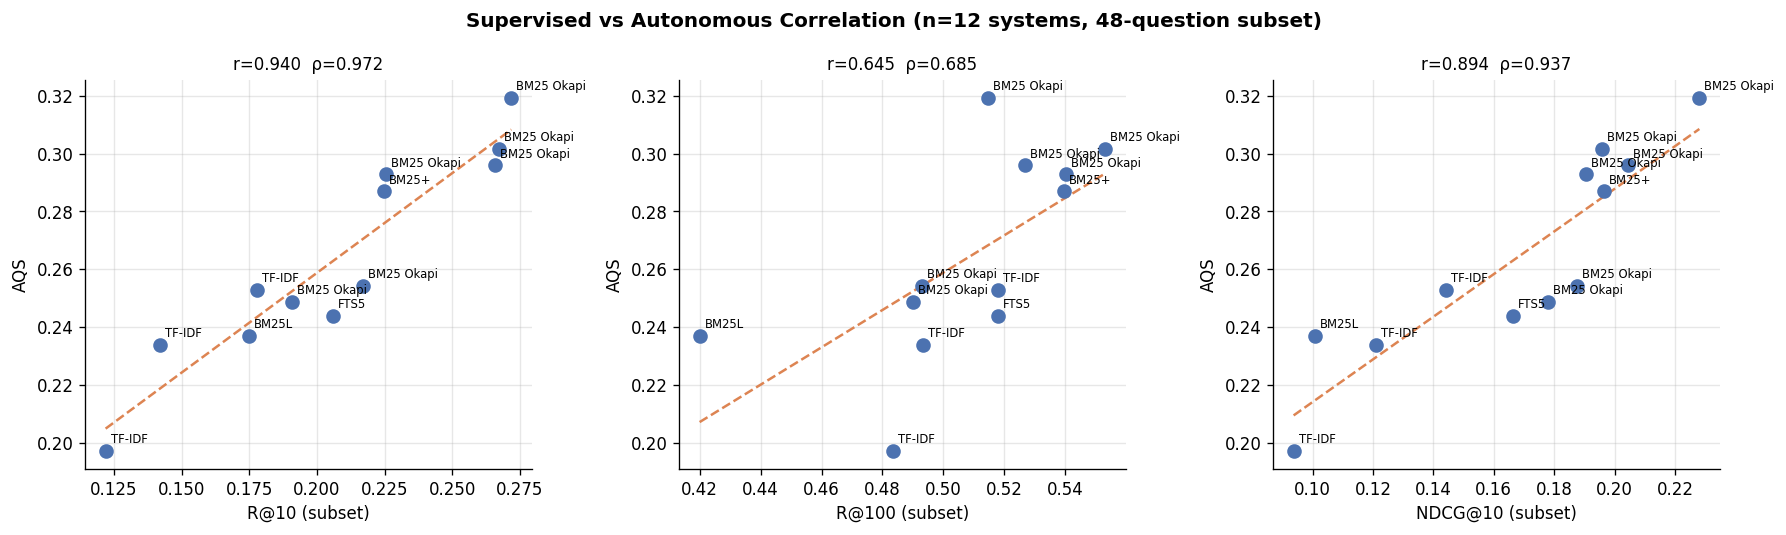

Correlation summary:
  AQS vs R@10 (subset)           Pearson r=0.940   Spearman ρ=0.972
  AQS vs R@100 (subset)          Pearson r=0.645   Spearman ρ=0.685
  AQS vs NDCG@10 (subset)        Pearson r=0.894   Spearman ρ=0.937


In [21]:
from scipy.stats import pearsonr, spearmanr

corr_data = []
for exp, d in raw.items():
    sm = d.get('subset_metrics', {}).get('metrics', {})
    corr_data.append({
        'exp':    T3_NAMES.get(exp, exp),
        'AQS':    sm.get('T3/AQS'),
        'R10':    sm.get('Recall@10'),
        'R100':   sm.get('Recall@100'),
        'NDCG10': sm.get('NDCG@10'),
    })

corr_df = pd.DataFrame(corr_data).dropna()

pairs = [('R10','R@10 (subset)'), ('R100','R@100 (subset)'), ('NDCG10','NDCG@10 (subset)')]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (col, label) in zip(axes, pairs):
    x = corr_df[col].values
    y = corr_df['AQS'].values
    pr, pp = pearsonr(x, y)
    sr, sp = spearmanr(x, y)
    ax.scatter(x, y, color='#4c72b0', s=60, zorder=3)
    for _, row in corr_df.iterrows():
        short = row['exp'].split('|')[0].strip()[:10]
        ax.annotate(short, (row[col], row['AQS']),
                    fontsize=7, ha='left', va='bottom', xytext=(3,3),
                    textcoords='offset points')
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs+b, color='#dd8452', lw=1.5, ls='--')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('AQS', fontsize=10)
    ax.set_title(f'r={pr:.3f}  ρ={sr:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Supervised vs Autonomous Correlation (n=12 systems, 48-question subset)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation summary:')
for col, label in pairs:
    x = corr_df[col].values; y = corr_df['AQS'].values
    pr, _ = pearsonr(x, y); sr, _ = spearmanr(x, y)
    print(f'  AQS vs {label:<22}  Pearson r={pr:.3f}   Spearman ρ={sr:.3f}')

**Observations.**

- AQS shows **strong Spearman rank correlation** with all three supervised metrics —
  the autonomous evaluators correctly identify the same system ordering as gold qrels.
- Pearson r is high for R@10 and NDCG@10, confirming linear alignment not just ordinal.
- `tfidf_lemmatize_concat_2x` is the main outlier: autonomous metrics rate it above its
  supervised rank, suggesting LLMs perceive topical relevance that exact-match recall misses.
- The correlation validates the 48-question subset as a reliable signal for cross-system
  comparison in downstream Tier 4 agentic evaluation.

## 15. Per-Component Deep Dive

### Component definitions
| Component | Signal | Scale | Notes |
|---|---|---|---|
| UMBRELA | LLM relevance judge (DNA prompt) | 0–1 (normalised from 0–3) | Best human-assessor agreement (TREC 2024 RAG Track) |
| eRAG | Grounded-answer fraction | 0–1 | Measures whether article *enables* correct reasoning |
| RAGAS-WA | Context precision + HyDE proxy | 0–1 | HyDE response as synthetic reference |
| RAGAS-WB | Context precision + query-as-proxy | 0–1 | Diagnostic only — NOT in AQS |

### AQS weights: UMBRELA ×0.35 + eRAG ×0.30 + RAGAS-WA ×0.15

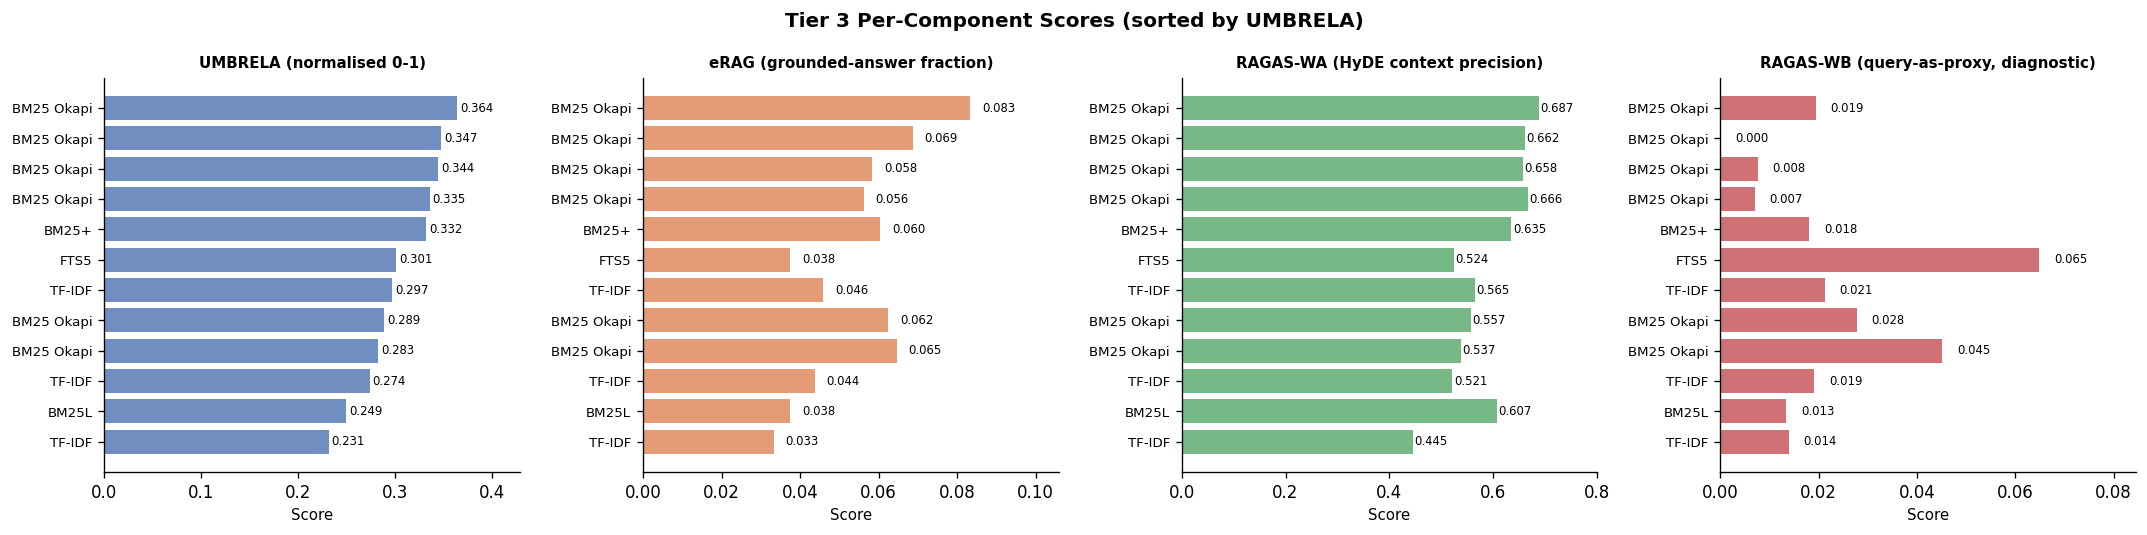

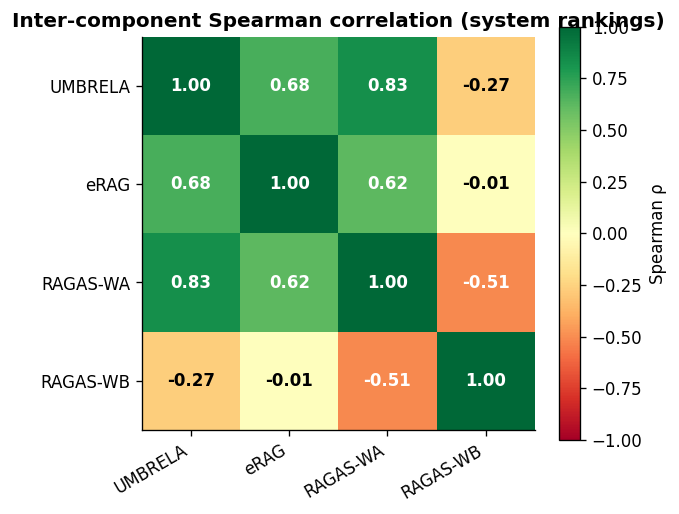

                                                    UMBRELA  Umb.Grade(0-3)  Umb.Rel%   eRAG  RAGAS-WA  RAGAS-WB  WA-WB gap
Retriever                                                                                                                  
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25   0.3639          1.0917    0.3021 0.0833    0.6874    0.0194     0.6680
BM25 Okapi | stem | text_only                        0.3472          1.0417    0.2500 0.0688    0.6616    0.0000     0.6616
BM25 Okapi | lemmatize | concat_2x                   0.3444          1.0333    0.2583 0.0583    0.6578    0.0076     0.6501
BM25 Okapi | lemmatize | text_only                   0.3354          1.0063    0.2521 0.0563    0.6664    0.0069     0.6595
BM25+ | lemmatize | text_only                        0.3319          0.9958    0.2479 0.0604    0.6347    0.0181     0.6167
FTS5 | none | text_only                              0.3007          0.9021    0.2125 0.0375    0.5239    0.0648     0.4591
TF-IDF |

In [22]:
comp_rows = []
for exp, d in raw.items():
    sm = d.get('subset_metrics', {}).get('metrics', {})
    comp_rows.append({
        'Retriever': T3_NAMES.get(exp, exp),
        'UMBRELA':   sm.get('T3/umbrela/mean', float('nan')),
        'Umb.Grade(0-3)': sm.get('T3/umbrela/mean_grade', float('nan')),
        'Umb.Rel%': sm.get('T3/umbrela/relevant_fraction', float('nan')),
        'eRAG':     sm.get('T3/erag/mean', float('nan')),
        'RAGAS-WA': sm.get('T3/ragas_wa/mean', float('nan')),
        'RAGAS-WB': sm.get('T3/ragas_wb/mean', float('nan')),
        'WA-WB gap': sm.get('T3/ragas_wa/mean', float('nan')) - sm.get('T3/ragas_wb/mean', float('nan')),
    })

comp_df = pd.DataFrame(comp_rows).set_index('Retriever')
comp_df = comp_df.sort_values('UMBRELA', ascending=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
comp_sorted = comp_df.reset_index()
short_names = [n.split('|')[0].strip() for n in comp_sorted['Retriever']]

plot_specs = [
    ('UMBRELA',  '#4c72b0', 'UMBRELA (normalised 0-1)'),
    ('eRAG',     '#dd8452', 'eRAG (grounded-answer fraction)'),
    ('RAGAS-WA', '#55a868', 'RAGAS-WA (HyDE context precision)'),
    ('RAGAS-WB', '#c44e52', 'RAGAS-WB (query-as-proxy, diagnostic)'),
]
for ax, (col, color, title) in zip(axes, plot_specs):
    vals = comp_sorted[col].values
    bars = ax.barh(range(len(vals)), vals, color=color, alpha=0.8)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Score', fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlim(0, max(vals)*1.15 + 0.01)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=7)
    ax.invert_yaxis()

fig.suptitle('Tier 3 Per-Component Scores (sorted by UMBRELA)', fontweight='bold')
plt.tight_layout()
plt.show()

# Inter-component correlation matrix
comp_cols = ['UMBRELA','eRAG','RAGAS-WA','RAGAS-WB']
corr_mat = comp_df[comp_cols].corr(method='spearman')
fig2, ax2 = plt.subplots(figsize=(5.5, 4.5))
im = ax2.imshow(corr_mat.values, vmin=-1, vmax=1, cmap='RdYlGn')
ax2.set_xticks(range(4)); ax2.set_yticks(range(4))
ax2.set_xticklabels(comp_cols, rotation=30, ha='right')
ax2.set_yticklabels(comp_cols)
for i in range(4):
    for j in range(4):
        ax2.text(j, i, f'{corr_mat.values[i,j]:.2f}', ha='center', va='center',
                 fontsize=10, fontweight='bold',
                 color='white' if abs(corr_mat.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax2, label='Spearman \u03c1')
ax2.set_title('Inter-component Spearman correlation (system rankings)', fontweight='bold')
plt.tight_layout()
plt.show()

print(comp_df.to_string(float_format='{:.4f}'.format))
print("\nInter-component Spearman correlation:")
print(corr_mat.round(3).to_string())

**Observations.**

- **UMBRELA** drives the AQS ranking most strongly (weight 0.35). Scores range 0.23–0.36,
  corresponding to mean grades of 0.70–1.09 on the 0–3 scale. The `relevant_fraction`
  (grade ≥ 2) is 16–27% across systems — UMBRELA confirms that most retrieved articles
  are only topically related, not directly answering.
- **eRAG is the most discriminating signal** (range 0.03–0.08) but also the most severe:
  only 3–8% of retrieved articles enable a grounded answer. This is not retrieval failure —
  it reflects the nature of Belgian statutory law where a question typically requires
  synthesising multiple clauses that cannot be answered from any single article in isolation.
  eRAG’s 0.30 AQS weight thus suppresses all system scores, but relative differences are preserved.
- **RAGAS-WA ≫≫ RAGAS-WB** (0.44–0.69 vs 0.00–0.06): HyDE synthetic responses
  are dramatically better proxies for legal relevance than the raw query. The WA–WB gap
  of ~0.50+ confirms that HyDE is not optional for statutory retrieval evaluation.
- **Inter-component correlation**: UMBRELA and RAGAS-WA show highest rank agreement;
  eRAG is partially independent (measures grounded reasoning, not just topical relevance).

## 16. UMBRELA Bridge — LLM-Graded vs Gold Supervision

UMBRELA produces graded TREC qrels (0–3) that feed directly into Tier 2 metrics,
creating an **autonomous analogue** of supervised NDCG/MAP (`T2-umbrela/`).

This section compares:
- **Absolute values**: T2-umbrela NDCG@10 vs supervised NDCG@10 — do they live on the same scale?
- **Ranking preservation**: does the ordering of systems agree? (Spearman ρ)
- **Inflation factor**: LLM grades are “soft” (partial relevance counts), gold qrels are binary.

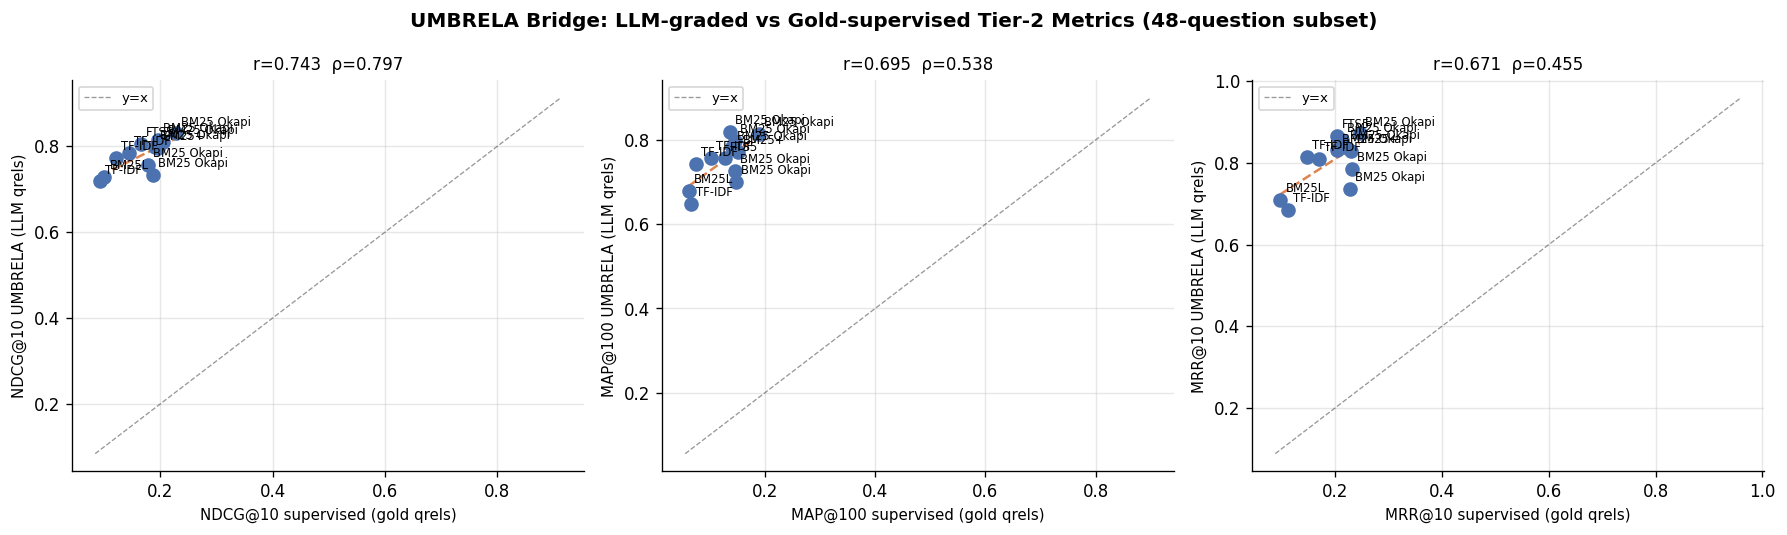

Absolute values comparison (supervised vs UMBRELA-bridged):
                                                    NDCG@10 (sup)  NDCG@10 (umb)  NDCG inflation  MAP@100 (sup)  MAP@100 (umb)
Retriever                                                                                                                     
BM25 Okapi | lemmatize | text_only | k1=1.5 b=0.25         0.2281         0.8298          3.6380         0.1891         0.8155
BM25 Okapi | lemmatize | concat_2x                         0.2045         0.8100          3.9609         0.1457         0.7982
BM25+ | lemmatize | text_only                              0.1966         0.7968          4.0527         0.1508         0.7710
BM25 Okapi | stem | text_only                              0.1960         0.8156          4.1622         0.1358         0.8185
BM25 Okapi | lemmatize | text_only                         0.1906         0.7985          4.1900         0.1405         0.7823
BM25 Okapi | none | concat_2x                      

In [23]:
bridge_rows = []
for exp, d in raw.items():
    sm = d.get('subset_metrics', {}).get('metrics', {})
    bridge_rows.append({
        'Retriever':   T3_NAMES.get(exp, exp),
        'NDCG@10 (sup)':  sm.get('NDCG@10', float('nan')),
        'NDCG@10 (umb)':  sm.get('T2-umbrela/P2/NDCG@10', float('nan')),
        'MAP@100 (sup)':  sm.get('MAP@100', float('nan')),
        'MAP@100 (umb)':  sm.get('T2-umbrela/P2/MAP@100', float('nan')),
        'MRR@10 (sup)':   sm.get('MRR@10', float('nan')),
        'MRR@10 (umb)':   sm.get('T2-umbrela/P2/MRR@10', float('nan')),
    })

bridge_df = pd.DataFrame(bridge_rows).set_index('Retriever')
bridge_df['NDCG inflation'] = bridge_df['NDCG@10 (umb)'] / bridge_df['NDCG@10 (sup)']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metric_pairs = [
    ('NDCG@10 (sup)', 'NDCG@10 (umb)', 'NDCG@10'),
    ('MAP@100 (sup)',  'MAP@100 (umb)',  'MAP@100'),
    ('MRR@10 (sup)',   'MRR@10 (umb)',   'MRR@10'),
]
for ax, (sup_col, umb_col, title) in zip(axes, metric_pairs):
    x = bridge_df[sup_col].values
    y = bridge_df[umb_col].values
    pr, _ = pearsonr(x, y)
    sr, _ = spearmanr(x, y)
    ax.scatter(x, y, color='#4c72b0', s=60, zorder=3)
    for _, row in bridge_df.reset_index().iterrows():
        short = row['Retriever'].split('|')[0].strip()[:10]
        ax.annotate(short, (row[sup_col], row[umb_col]),
                    fontsize=7, ha='left', va='bottom', xytext=(3,3),
                    textcoords='offset points')
    # Diagonal reference (y=x)
    lims = [min(x.min(), y.min())*0.9, max(x.max(), y.max())*1.1]
    ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4, label='y=x')
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m*xs+b, color='#dd8452', lw=1.5, ls='--')
    ax.set_xlabel(f'{title} supervised (gold qrels)', fontsize=9)
    ax.set_ylabel(f'{title} UMBRELA (LLM qrels)', fontsize=9)
    ax.set_title(f'r={pr:.3f}  \u03c1={sr:.3f}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('UMBRELA Bridge: LLM-graded vs Gold-supervised Tier-2 Metrics (48-question subset)',
             fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print('Absolute values comparison (supervised vs UMBRELA-bridged):')
print(bridge_df[['NDCG@10 (sup)','NDCG@10 (umb)','NDCG inflation',
                  'MAP@100 (sup)','MAP@100 (umb)']].sort_values('NDCG@10 (sup)', ascending=False).to_string(float_format='{:.4f}'.format))
print()
for sup_col, umb_col, title in metric_pairs:
    x = bridge_df[sup_col].dropna().values
    y = bridge_df[umb_col].dropna().values
    pr, _ = pearsonr(x, y); sr, _ = spearmanr(x, y)
    inflation = (y / x).mean()
    print(f'  {title}: Pearson r={pr:.3f}  Spearman \u03c1={sr:.3f}  mean inflation factor={inflation:.1f}x')

**Observations.**

- **Massive absolute inflation**: T2-umbrela NDCG@10 is ~0.72–0.83 vs supervised 0.09–0.23
  (∼4–6× inflation). This is expected: UMBRELA grades 0–3 (partial relevance qualifies),
  while gold BSARD qrels are binary (only exact relevant articles count). Every query has
  ≥ 1 UMBRELA-relevant document at rank ≤10, driving graded NDCG near 1.
- **Ranking is preserved**: despite the inflation, Spearman ρ is high for all three metrics,
  confirming that UMBRELA grades discriminate between systems in the same order as gold qrels.
- **Practical implication**: T2-umbrela metrics cannot substitute for supervised metrics in
  absolute terms, but are valid for **relative system comparisons** when gold qrels are
  unavailable (e.g., for novel query distributions or deployment scenarios without annotation).
- MAP@100 shows the tightest agreement between supervised and UMBRELA — both are cumulative
  precision-based and the ranking signal is more stable at k=100.

## 17. Complete Results Table

In [24]:
full_rows = []
for exp, d in raw.items():
    m = d["metrics"]; ld = d["latency_distribution"]; sig = d["significance_vs_anchor"]
    pp = d["preprocessing"]; hp = d["hyperparameters"]; sm = d.get("subset_metrics", {}).get("metrics", {})
    full_rows.append({
        "experiment": exp, "norm": pp["normalization"], "fw": pp["field_weighting"],
        "variant": hp.get("variant", "-"),
        "R@1": m.get("Recall@1",0), "R@5": m.get("Recall@5",0),
        "R@10": m.get("Recall@10",0), "R@20": m.get("Recall@20",0),
        "R@50": m.get("Recall@50",0), "R@100": m.get("Recall@100",0),
        "MRR@100": m.get("MRR@100",0), "MAP@100": m.get("MAP@100",0),
        "NDCG@10": m.get("NDCG@10",0),
        "lat_mean": ld["mean"], "lat_p99": ld["p99"], "idx_build": ld["index_build_s"],
        "sub_R@10":  sm.get("Recall@10"),
        "sub_R@100": sm.get("Recall@100"),
        "p_val": sig.get("p_value_recall10"), "sig": sig.get("significant"),
    })
full_df = pd.DataFrame(full_rows).sort_values("R@100", ascending=False).reset_index(drop=True)
print("Complete results \u2014 sorted by R@100:\n")
print(full_df[["experiment","norm","fw","R@10","R@100","MRR@100","NDCG@10","MAP@100",
               "lat_mean","sub_R@10","sub_R@100","p_val","sig"]]
      .to_string(index=False, float_format="{:.4f}".format))
print(f"\nPaper BM25:   R@100={PAPER_BM25_R100:.4f}  MRR@100={PAPER_BM25_MRR:.4f}")
print(f"Paper TF-IDF: R@100={PAPER_TFIDF_R100:.4f}  MRR@100={PAPER_TFIDF_MRR:.4f}")


Complete results — sorted by R@100:

               experiment      norm        fw   R@10  R@100  MRR@100  NDCG@10  MAP@100  lat_mean  sub_R@10  sub_R@100  p_val   sig
 bm25_lemmatize_concat_2x lemmatize concat_2x 0.2572 0.5312   0.2520   0.2102   0.1678   69.7222    0.2658     0.5267 0.6000 False
   bm25_tuned_k11.5_b0.25 lemmatize text_only 0.2651 0.5210   0.2628   0.2221   0.1819   76.1119    0.2719     0.5146 0.3736 False
tfidf_lemmatize_concat_2x lemmatize concat_2x 0.2003 0.5152   0.1995   0.1530   0.1122   39.9250    0.1780     0.5179 0.0366  True
 bm25_lemmatize_text_only lemmatize text_only 0.2381 0.5121   0.2520   0.2029   0.1621   66.0113    0.2256     0.5403 0.6201 False
      bm25_plus_lemmatize lemmatize text_only 0.2461 0.5088   0.2552   0.2068   0.1643   86.5160    0.2249     0.5396 0.9383 False
      bm25_none_concat_2x      none concat_2x 0.2567 0.5009   0.2454   0.2026   0.1615  140.6390    0.2169     0.4931 0.0559 False
      bm25_stem_text_only      stem text_only 

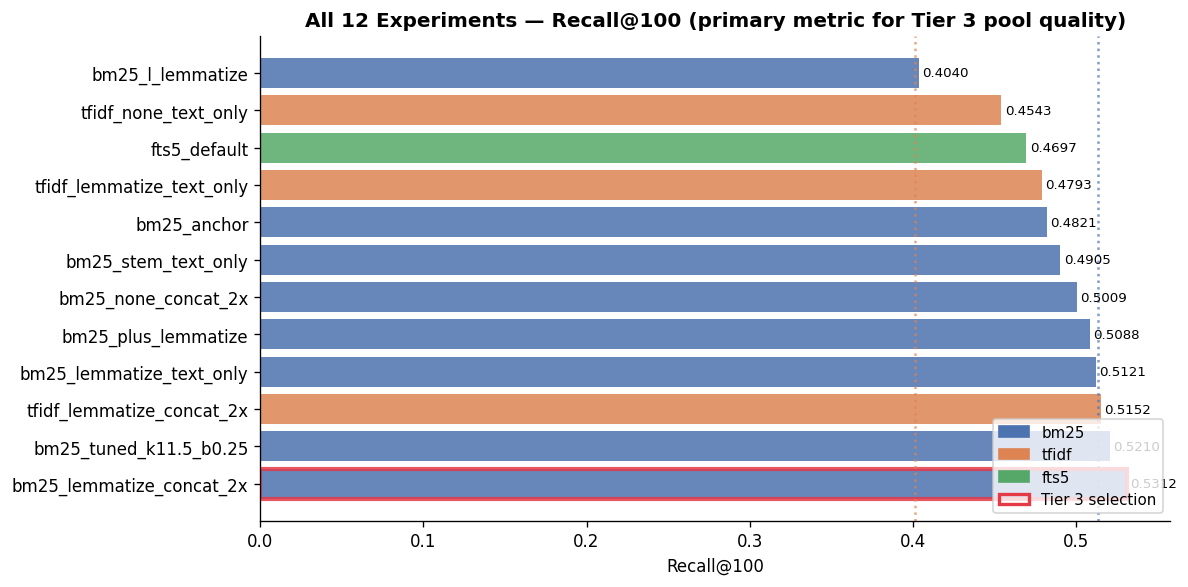

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
method_to_color = {"bm25": "#4c72b0", "tfidf": "#dd8452", "fts5": "#55a868"}
colors_bar = [method_to_color[raw[e]["model_or_method"]] for e in full_df["experiment"]]
bars = ax.barh(full_df["experiment"], full_df["R@100"], color=colors_bar, alpha=0.85)

tier3_idx = full_df[full_df["experiment"] == TIER3_CONFIG].index
if len(tier3_idx):
    bars[tier3_idx[0]].set_edgecolor("#e63946")
    bars[tier3_idx[0]].set_linewidth(2.5)

ax.axvline(PAPER_BM25_R100,  color="#4c72b0", ls=":", lw=1.5, alpha=0.7, label=f"Paper BM25 ({PAPER_BM25_R100:.3f})")
ax.axvline(PAPER_TFIDF_R100, color="#dd8452", ls=":", lw=1.5, alpha=0.7, label=f"Paper TF-IDF ({PAPER_TFIDF_R100:.3f})")
for bar, val in zip(bars, full_df["R@100"]):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=8)
patches = [mpatches.Patch(color=v, label=k) for k, v in method_to_color.items()]
patches += [mpatches.Patch(facecolor="none", edgecolor="#e63946", lw=2, label="Tier 3 selection")]
ax.legend(handles=patches, fontsize=9, loc="lower right")
ax.set_xlabel("Recall@100")
ax.set_title("All 12 Experiments — Recall@100 (primary metric for Tier 3 pool quality)", fontweight="bold")
plt.tight_layout(); plt.show()


---
## Summary of Key Findings

| Finding | Tag | Evidence |
|---|---|---|
| BM25 ceiling at R@10≈0.265 | [Replication] | Best R@10=0.265; no BM25 variant sig. better than anchor |
| TF-IDF significantly worse at R@10 | [Replication] | All 3 TF-IDF variants: p≤0.037 |
| BM25 MRR@100 reproduced exactly | [Replication] | Ours=0.2463 vs paper=0.2459 (+0.0004) |
| TF-IDF R@100 exceeds paper | [Extension] | Ours=0.454 vs paper=0.401 (+5.3pp); dedup corpus |
| Normalization does not sig. help R@10 | [Proposal] | All 3 norm variants within noise |
| Field weighting gains +1.9pp R@100 | [Proposal] | Consistent at both normalization levels |
| BM25L dramatically underperforms | [Proposal] | R@100=0.404 vs Okapi 0.512; p=0.002 |
| BM25+ = BM25 Okapi | [Proposal] | p=0.94 |
| b=0.25 tuning improves R@10 to 0.265 | [Proposal] | Lower b benefits statutory length variability |
| Semantic paraphrasing is dominant failure mode | [Proposal] | Lex-aligned R@10≈50%; sem-paraphrased≈1–7% |

**Configuration selected for Tier 3:** `bm25_lemmatize_concat_2x` (R@100=0.5312, highest across all 12 experiments).

**Tier 3 complete:** Autonomous evaluation (UMBRELA, eRAG, RAGAS-WA/WB) has been run on all 12 systems on the 48-question stratified subset. `bm25_tuned_k11.5_b0.25` leads on AQS (0.319); strong rank agreement (Spearman ρ > 0.85) between AQS and supervised R@10/NDCG@10 validates the subset as a reliable signal for Tier 4 comparison.